In [1]:
import os
import math
import time
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn.functional as F

try:
    from tqdm import tqdm
except ModuleNotFoundError:
    tqdm = lambda x, **kwargs: x

In [2]:
!pwd

/Users/ronit/Desktop/QeFEM/main/maxcut_results/v2


In [3]:
K2000_HIST_BEST = 33337

In [4]:
DATA_MAXCUT_DIR = Path("./../../data-maxcut")
RESULTS_DIR = Path(".")
OUT_DIR = RESULTS_DIR / "qefem_v2_res"
OUT_DIR.mkdir(parents=True, exist_ok=True)

GSET_HIST_PATH = RESULTS_DIR / "gset_validation.txt"
GSET_VANILLA_PATH = RESULTS_DIR / "naive_vanilla_fem_G1-G54_full_results.csv"
GSET_QEFEM_V1_PATH = RESULTS_DIR / "qefem_v1_benchmark_table.csv"
K2000_RESULTS_PATH = RESULTS_DIR / "K2000_adam_anneal_vs_baselines_comparison.csv"

DEVICE = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
DTYPE = torch.float32

In [5]:
def build_gset_history_df(hist_path=GSET_HIST_PATH, out_dir=OUT_DIR):
    rows = []

    with open(hist_path, "r") as f:
        for line in f:
            if not line.strip():
                continue

            g_idx, best_cut = line.split()[:2]
            g_idx = int(g_idx)

            if 1 <= g_idx <= 54:
                rows.append({
                    "instance": f"G{g_idx}",
                    "best_known_cut": float(best_cut),
                })

    df = pd.DataFrame(rows)
    df.to_csv(out_dir / "gset_history_best_G1-G54.csv", index=False)
    return df

def build_gset_vanilla_best_df(vanilla_path=GSET_VANILLA_PATH, out_dir=OUT_DIR):
    df_raw = pd.read_csv(vanilla_path)

    df = df_raw.loc[:, ["instance", "vanilla_fem_best_cut", "gap"]].copy()
    df = df.rename(columns={
        "instance": "graph_name",
        "vanilla_fem_best_cut": "cut_value",
    })

    df.to_csv(out_dir / "gset_vanilla_best_G1-G54.csv", index=False)
    return df

def build_gset_qefem_v1_best_df(qefem_v1_path=GSET_QEFEM_V1_PATH, out_dir=OUT_DIR):
    df_raw = pd.read_csv(qefem_v1_path)

    df = df_raw.copy()
    df["g_idx"] = df["instance"].str.replace("G", "", regex=False).astype(int)
    df = df[(df["g_idx"] >= 1) & (df["g_idx"] <= 54)]

    df = df.loc[:, ["instance", "v1_best", "v1_gap"]].copy()
    df = df.rename(columns={
        "instance": "graph_name",
        "v1_best": "cut_value",
        "v1_gap": "gap",
    })

    df.to_csv(out_dir / "gset_qefem_v1_best_G1-G54.csv", index=False)
    return df

def build_k2000_vanilla_best_df(k2000_path=K2000_RESULTS_PATH, out_dir=OUT_DIR):
    df_raw = pd.read_csv(k2000_path)

    df = df_raw[df_raw["method"].str.startswith("vanilla")].copy()
    df = df.loc[:, ["method", "cut", "gap"]]
    df = df.rename(columns={
        "method": "graph_name",
        "cut": "cut_value",
    })

    df.to_csv(out_dir / "k2000_vanilla_best.csv", index=False)
    return df

def build_k2000_qefem_v1_best_df(k2000_path=K2000_RESULTS_PATH, out_dir=OUT_DIR):
    df_raw = pd.read_csv(k2000_path)

    df = df_raw[df_raw["method"].str.startswith("QEFEM")].copy()
    df = df.loc[:, ["method", "cut", "gap"]]
    df = df.rename(columns={
        "method": "graph_name",
        "cut": "cut_value",
    })

    df.to_csv(out_dir / "k2000_qefem_v1_best.csv", index=False)
    return df

def build_all_reference_dfs():
    gset_history_df = build_gset_history_df()
    gset_vanilla_df = build_gset_vanilla_best_df()
    gset_qefem_v1_df = build_gset_qefem_v1_best_df()
    k2000_vanilla_df = build_k2000_vanilla_best_df()
    k2000_qefem_v1_df = build_k2000_qefem_v1_best_df()

    return {
        "gset_history": gset_history_df,
        "gset_vanilla": gset_vanilla_df,
        "gset_qefem_v1": gset_qefem_v1_df,
        "k2000_vanilla": k2000_vanilla_df,
        "k2000_qefem_v1": k2000_qefem_v1_df,
    }

In [6]:
reference_dfs = build_all_reference_dfs()

In [7]:
#reference_dfs["k2000_vanilla"]
reference_dfs["k2000_qefem_v1"]
#reference_dfs["gset_vanilla"]
#reference_dfs["gset_qefem_v1"]

,graph_name,cut_value,gap
2,QEFEM_gamma0_Adam,30657.0,2680.0
3,QEFEM_Adam_gamma_anneal,32981.0,356.0


In [8]:
def load_gset_dense(g_idx, data_dir=DATA_MAXCUT_DIR, device=DEVICE, dtype=DTYPE):
    if not (1 <= int(g_idx) <= 54):
        raise ValueError("g_idx must be between 1 and 54.")

    path = data_dir / f"G{int(g_idx)}"

    with open(path, "r") as f:
        n, m = map(int, f.readline().split())

        W_cpu = torch.zeros((n, n), dtype=dtype, device="cpu")

        for _ in range(m):
            i, j, w = f.readline().split()
            i = int(i) - 1
            j = int(j) - 1
            w = float(w)

            W_cpu[i, j] = w
            W_cpu[j, i] = w

    return W_cpu.to(device=device)

def load_k2000_dense(data_dir=DATA_MAXCUT_DIR, device=DEVICE, dtype=DTYPE):
    path = data_dir / "k2000"

    with open(path, "r") as f:
        n, m = map(int, f.readline().split())

        W_cpu = torch.zeros((n, n), dtype=dtype, device="cpu")

        for _ in range(m):
            i, j, w = f.readline().split()
            i = int(i) - 1
            j = int(j) - 1
            w = float(w)

            W_cpu[i, j] = w
            W_cpu[j, i] = w

    return W_cpu.to(device=device)

In [9]:
W_G4 = load_gset_dense(4)
print("G4:", W_G4.shape, W_G4.device, W_G4.dtype)

G4: torch.Size([800, 800]) mps:0 torch.float32


In [13]:
W_G4.shape

torch.Size([800, 800])

### HYPERPARAMETERS!

In [12]:
EPS = 1e-8
GRAD_CLIP_DEFAULT = 1.0
BLOCH_LENGTH_INIT = 1e-2
FIELD_NOISE = 1e-3
THETA_INIT = math.pi / 2
THETA_NOISE = 1e-3

In [13]:
def print_gset_hparam_help():
    print(
        """
get_gset_local_hparams input sequence:

Required:
    g_idx

Common tunables:
    n_batch
    n_rep
    n_steps
    optimizer
    lr
    grad_type
    grad_clip
    T_max
    T_min
    beta_schedule
    gamma_max
    gamma_min
    gamma_schedule

Adam tunables:
    adam_betas
    adam_weight_decay

RMSprop tunables:
    rmsprop_alpha
    rmsprop_momentum
    rmsprop_weight_decay

Example:
    hp = get_gset_local_hparams(
        4,
        n_batch=10000,
        n_rep=1,
        n_steps=1000,
        optimizer="adam",
        lr=1e-2,
        grad_type="explicit",
        T_max=0.5,
        T_min=8e-5,
        beta_schedule="exponential_beta",
        gamma_max=1.0,
        gamma_min=1e-3,
        gamma_schedule="exponential",
    )
"""
    )


def get_gset_local_hparams(
    g_idx,
    *,
    n_batch=10000,
    n_rep=1,
    n_steps=1000,

    optimizer="adam",
    lr=1e-2,

    adam_betas=(0.9, 0.999),
    adam_weight_decay=0.0,

    rmsprop_alpha=0.99,
    rmsprop_momentum=0.0,
    rmsprop_weight_decay=0.0,

    grad_type="auto",
    grad_clip=GRAD_CLIP_DEFAULT,

    T_max=0.5,
    T_min=8e-5,
    beta_schedule="exponential_beta",

    gamma_max=1.0,
    gamma_min=1e-3,
    gamma_schedule="exponential",

    show_help=False,
):
    if show_help:
        print_gset_hparam_help()

    if not isinstance(g_idx, int):
        print("ERROR: g_idx must be an integer.")
        print_gset_hparam_help()
        raise TypeError("g_idx must be an integer.")

    if g_idx < 1 or g_idx > 54:
        print("ERROR: g_idx must be between 1 and 54.")
        print_gset_hparam_help()
        raise ValueError("g_idx must be between 1 and 54.")

    optimizer = optimizer.lower()
    grad_type = grad_type.lower()
    beta_schedule = beta_schedule.lower()
    gamma_schedule = gamma_schedule.lower()

    if optimizer not in ["adam", "rmsprop"]:
        print("ERROR: optimizer must be either 'adam' or 'rmsprop'.")
        print_gset_hparam_help()
        raise ValueError("Invalid optimizer.")

    if grad_type not in ["auto", "explicit"]:
        print("ERROR: grad_type must be either 'auto' or 'explicit'.")
        print_gset_hparam_help()
        raise ValueError("Invalid grad_type.")

    if beta_schedule not in ["linear_temperature", "linear_beta", "exponential_beta"]:
        print("ERROR: beta_schedule must be one of:")
        print("    'linear_temperature', 'linear_beta', 'exponential_beta'")
        print_gset_hparam_help()
        raise ValueError("Invalid beta_schedule.")

    if gamma_schedule not in ["linear", "exponential", "constant"]:
        print("ERROR: gamma_schedule must be one of:")
        print("    'linear', 'exponential', 'constant'")
        print_gset_hparam_help()
        raise ValueError("Invalid gamma_schedule.")

    if n_batch <= 0:
        print("ERROR: n_batch must be positive.")
        print_gset_hparam_help()
        raise ValueError("Invalid n_batch.")

    if n_rep <= 0:
        print("ERROR: n_rep must be positive.")
        print_gset_hparam_help()
        raise ValueError("Invalid n_rep.")

    if n_steps <= 0:
        print("ERROR: n_steps must be positive.")
        print_gset_hparam_help()
        raise ValueError("Invalid n_steps.")

    if lr <= 0:
        print("ERROR: lr must be positive.")
        print_gset_hparam_help()
        raise ValueError("Invalid lr.")

    if T_max <= 0 or T_min <= 0:
        print("ERROR: T_max and T_min must both be positive.")
        print_gset_hparam_help()
        raise ValueError("Invalid temperature range.")

    if gamma_max < 0 or gamma_min < 0:
        print("ERROR: gamma_max and gamma_min must be non-negative.")
        print_gset_hparam_help()
        raise ValueError("Invalid gamma range.")

    return {
        "graph_name": f"G{g_idx}",

        "n_batch": int(n_batch),
        "n_rep": int(n_rep),
        "n_steps": int(n_steps),

        "optimizer": optimizer,
        "lr": float(lr),

        "adam_betas": adam_betas,
        "adam_weight_decay": float(adam_weight_decay),

        "rmsprop_alpha": float(rmsprop_alpha),
        "rmsprop_momentum": float(rmsprop_momentum),
        "rmsprop_weight_decay": float(rmsprop_weight_decay),

        "grad_type": grad_type,
        "gradient_mode": grad_type,
        "grad_clip": grad_clip,

        "T_max": float(T_max),
        "T_min": float(T_min),
        "beta_schedule": beta_schedule,

        "gamma_max": float(gamma_max),
        "gamma_min": float(gamma_min),
        "gamma_schedule": gamma_schedule,
    }

In [14]:
def print_k2000_hparam_help():
    print(
        """
get_k2000_local_hparams input sequence:

Common tunables:
    n_batch
    n_rep
    n_steps
    optimizer
    lr
    grad_type
    grad_clip
    T_max
    T_min
    beta_schedule
    gamma_max
    gamma_min
    gamma_schedule

Adam tunables:
    adam_betas
    adam_weight_decay

RMSprop tunables:
    rmsprop_alpha
    rmsprop_momentum
    rmsprop_weight_decay

Example:
    hp = get_k2000_local_hparams(
        n_batch=10000,
        n_rep=1,
        n_steps=1000,
        optimizer="rmsprop",
        lr=3e-2,
        rmsprop_alpha=0.56,
        rmsprop_momentum=0.63,
        rmsprop_weight_decay=0.013,
        grad_type="explicit",
        T_max=1.16,
        T_min=6e-5,
        beta_schedule="linear_temperature",
        gamma_max=1.0,
        gamma_min=1e-3,
        gamma_schedule="exponential",
    )
"""
    )


def get_k2000_local_hparams(
    *,
    n_batch=10000,
    n_rep=1,
    n_steps=1000,

    optimizer="adam",
    lr=None,

    adam_betas=(0.9, 0.999),
    adam_weight_decay=0.0,

    rmsprop_alpha=0.56,
    rmsprop_momentum=0.63,
    rmsprop_weight_decay=0.013,

    grad_type="auto",
    grad_clip=GRAD_CLIP_DEFAULT,

    T_max=1.16,
    T_min=6e-5,
    beta_schedule="linear_temperature",

    gamma_max=1.0,
    gamma_min=1e-3,
    gamma_schedule="exponential",

    show_help=False,
):
    if show_help:
        print_k2000_hparam_help()

    optimizer = optimizer.lower()
    grad_type = grad_type.lower()
    beta_schedule = beta_schedule.lower()
    gamma_schedule = gamma_schedule.lower()

    if optimizer not in ["adam", "rmsprop"]:
        print("ERROR: optimizer must be either 'adam' or 'rmsprop'.")
        print_k2000_hparam_help()
        raise ValueError("Invalid optimizer.")

    if lr is None:
        if optimizer == "adam":
            lr = 1e-2
        elif optimizer == "rmsprop":
            lr = 3e-2

    if grad_type not in ["auto", "explicit"]:
        print("ERROR: grad_type must be either 'auto' or 'explicit'.")
        print_k2000_hparam_help()
        raise ValueError("Invalid grad_type.")

    if beta_schedule not in ["linear_temperature", "linear_beta", "exponential_beta"]:
        print("ERROR: beta_schedule must be one of:")
        print("    'linear_temperature', 'linear_beta', 'exponential_beta'")
        print_k2000_hparam_help()
        raise ValueError("Invalid beta_schedule.")

    if gamma_schedule not in ["linear", "exponential", "constant"]:
        print("ERROR: gamma_schedule must be one of:")
        print("    'linear', 'exponential', 'constant'")
        print_k2000_hparam_help()
        raise ValueError("Invalid gamma_schedule.")

    if n_batch <= 0:
        print("ERROR: n_batch must be positive.")
        print_k2000_hparam_help()
        raise ValueError("Invalid n_batch.")

    if n_rep <= 0:
        print("ERROR: n_rep must be positive.")
        print_k2000_hparam_help()
        raise ValueError("Invalid n_rep.")

    if n_steps <= 0:
        print("ERROR: n_steps must be positive.")
        print_k2000_hparam_help()
        raise ValueError("Invalid n_steps.")

    if lr <= 0:
        print("ERROR: lr must be positive.")
        print_k2000_hparam_help()
        raise ValueError("Invalid lr.")

    if T_max <= 0 or T_min <= 0:
        print("ERROR: T_max and T_min must both be positive.")
        print_k2000_hparam_help()
        raise ValueError("Invalid temperature range.")

    if gamma_max < 0 or gamma_min < 0:
        print("ERROR: gamma_max and gamma_min must be non-negative.")
        print_k2000_hparam_help()
        raise ValueError("Invalid gamma range.")

    return {
        "graph_name": f"K2000_{optimizer}",

        "n_batch": int(n_batch),
        "n_rep": int(n_rep),
        "n_steps": int(n_steps),

        "optimizer": optimizer,
        "lr": float(lr),

        "adam_betas": adam_betas,
        "adam_weight_decay": float(adam_weight_decay),

        "rmsprop_alpha": float(rmsprop_alpha),
        "rmsprop_momentum": float(rmsprop_momentum),
        "rmsprop_weight_decay": float(rmsprop_weight_decay),

        "grad_type": grad_type,
        "gradient_mode": grad_type,
        "grad_clip": grad_clip,

        "T_max": float(T_max),
        "T_min": float(T_min),
        "beta_schedule": beta_schedule,

        "gamma_max": float(gamma_max),
        "gamma_min": float(gamma_min),
        "gamma_schedule": gamma_schedule,
    }

In [15]:
g4_exp = get_gset_local_hparams(
    4,
    n_batch=10000,
    n_rep=1,
    n_steps=2000,
    optimizer="adam",
    lr=1e-2,
    grad_type="auto",
    grad_clip=1.0,
    T_max=0.5,
    T_min=8e-5,
    beta_schedule="exponential_beta",
    gamma_max=1.0,
    gamma_min=1e-3,
    gamma_schedule="exponential",
)

g4_lin = get_gset_local_hparams(
    4,
    n_batch=10000,
    n_rep=1,
    n_steps=2000,
    optimizer="adam",
    lr=1e-2,
    grad_type="auto",
    grad_clip=1.0,
    T_max=0.5,
    T_min=8e-5,
    beta_schedule="linear_temperature",
    gamma_max=1.0,
    gamma_min=1e-3,
    gamma_schedule="linear",
)

k2000_hparams = hp_k2000 = get_k2000_local_hparams(
    n_batch=10000,
    n_rep=1,
    n_steps=1000,
    optimizer="rmsprop",
    lr=3e-2,
    rmsprop_alpha=0.56,
    rmsprop_momentum=0.63,
    rmsprop_weight_decay=0.013,
    grad_type="explicit",
    grad_clip=1.0,
    T_max=1.16,
    T_min=6e-5,
    beta_schedule="exponential_beta",
    gamma_max=1.0,
    gamma_min=1e-3,
    gamma_schedule="exponential",
)

g4_lin, g4_exp, k2000_hparams

({'graph_name': 'G4',
  'n_batch': 10000,
  'n_rep': 1,
  'n_steps': 2000,
  'optimizer': 'adam',
  'lr': 0.01,
  'adam_betas': (0.9, 0.999),
  'adam_weight_decay': 0.0,
  'rmsprop_alpha': 0.99,
  'rmsprop_momentum': 0.0,
  'rmsprop_weight_decay': 0.0,
  'grad_type': 'auto',
  'gradient_mode': 'auto',
  'grad_clip': 1.0,
  'T_max': 0.5,
  'T_min': 8e-05,
  'beta_schedule': 'linear_temperature',
  'gamma_max': 1.0,
  'gamma_min': 0.001,
  'gamma_schedule': 'linear'},
 {'graph_name': 'G4',
  'n_batch': 10000,
  'n_rep': 1,
  'n_steps': 2000,
  'optimizer': 'adam',
  'lr': 0.01,
  'adam_betas': (0.9, 0.999),
  'adam_weight_decay': 0.0,
  'rmsprop_alpha': 0.99,
  'rmsprop_momentum': 0.0,
  'rmsprop_weight_decay': 0.0,
  'grad_type': 'auto',
  'gradient_mode': 'auto',
  'grad_clip': 1.0,
  'T_max': 0.5,
  'T_min': 8e-05,
  'beta_schedule': 'exponential_beta',
  'gamma_max': 1.0,
  'gamma_min': 0.001,
  'gamma_schedule': 'exponential'},
 {'graph_name': 'K2000_rmsprop',
  'n_batch': 10000,
  

### FREE ENERGY FUNCTIONS!

In [16]:
def logit_from_value(x, device=DEVICE, dtype=DTYPE, eps=EPS):
    x = torch.tensor(x, device=device, dtype=dtype)
    x = x.clamp(eps, 1.0 - eps)
    return torch.logit(x)
################################################################################

def bloch_from_fields(fields, theta):
    R = torch.sigmoid(fields)
    rx = R * torch.sin(theta)
    rz = R * torch.cos(theta)
    return R, rx, rz
################################################################################

def discrete_cut(W, spins):
    single_input = False

    if spins.dim() == 1:
        spins = spins.unsqueeze(0)
        single_input = True

    spins = spins.to(device=W.device, dtype=W.dtype)

    quad = torch.einsum("ri,ij,rj->r", spins, W, spins)
    cut = 0.25 * (W.sum() - quad)

    if single_input:
        return cut.squeeze(0)

    return cut
################################################################################

def expected_cut(W, rz):
    single_input = False

    if rz.dim() == 1:
        rz = rz.unsqueeze(0)
        single_input = True

    rz = rz.to(device=W.device, dtype=W.dtype)

    quad = torch.einsum("ri,ij,rj->r", rz, W, rz)
    cut = 0.25 * (W.sum() - quad)

    if single_input:
        return cut.squeeze(0)

    return cut
################################################################################

def quantum_entropy(R, eps=EPS):
    single_input = False

    if R.dim() == 1:
        R = R.unsqueeze(0)
        single_input = True

    R = R.clamp(eps, 1.0 - eps)

    lam_plus = 0.5 * (1.0 + R)
    lam_minus = 0.5 * (1.0 - R)

    S_site = -(
        lam_plus * torch.log(lam_plus)
        + lam_minus * torch.log(lam_minus)
    )

    S = S_site.sum(dim=1)

    if single_input:
        return S.squeeze(0)

    return S
################################################################################

def transverse_driver_energy(rx, gamma):
    single_input = False

    if rx.dim() == 1:
        rx = rx.unsqueeze(0)
        single_input = True

    gamma = torch.as_tensor(gamma, device=rx.device, dtype=rx.dtype)

    E_driver = -gamma * rx.sum(dim=1)

    if single_input:
        return E_driver.squeeze(0)

    return E_driver
################################################################################
################################################################################


def qefem_free_energy(W, fields, theta, beta, gamma, eps=EPS):
    beta = torch.as_tensor(beta, device=W.device, dtype=W.dtype)
    gamma = torch.as_tensor(gamma, device=W.device, dtype=W.dtype)

    R, rx, rz = bloch_from_fields(fields, theta)

    cut_exp = expected_cut(W, rz)
    entropy = quantum_entropy(R, eps=eps)
    driver = transverse_driver_energy(rx, gamma)

    internal_energy = -cut_exp

    F = internal_energy + driver - entropy / beta

    aux = {
        "R": R,
        "rx": rx,
        "rz": rz,
        "expected_cut": cut_exp,
        "entropy": entropy,
        "driver_energy": driver,
        "internal_energy": internal_energy,
        "free_energy": F,
        "beta": beta,
        "gamma": gamma,
    }

    return F, aux
################################################################################

def explicit_qefem_binary_gradients(W, fields, theta, beta, gamma, eps=EPS):
    beta = torch.as_tensor(beta, device=W.device, dtype=W.dtype)
    gamma = torch.as_tensor(gamma, device=W.device, dtype=W.dtype)

    R, rx, rz = bloch_from_fields(fields, theta)

    R_safe = R.clamp(eps, 1.0 - eps)

    hz = rz @ W

    entropy_force = torch.atanh(R_safe) / beta

    grad_fields = R * (1.0 - R) * (
        0.5 * hz * torch.cos(theta)
        - gamma * torch.sin(theta)
        + entropy_force
    )

    grad_theta = (
        -0.5 * R * hz * torch.sin(theta)
        - gamma * R * torch.cos(theta)
    )

    return grad_fields, grad_theta

################################################################################
def make_beta_schedule(local_hparams, device=DEVICE, dtype=DTYPE):
    n_steps = int(local_hparams["n_steps"])
    T_max = float(local_hparams["T_max"])
    T_min = float(local_hparams["T_min"])

    beta_schedule = local_hparams.get("beta_schedule", "linear_temperature").lower()

    if n_steps <= 0:
        raise ValueError("n_steps must be positive.")

    if T_max <= 0 or T_min <= 0:
        raise ValueError("T_max and T_min must be positive.")

    if beta_schedule == "linear_temperature":
        T = torch.linspace(T_max, T_min, n_steps, device=device, dtype=dtype)
        beta = 1.0 / T

    elif beta_schedule == "linear_beta":
        beta_min = 1.0 / T_max
        beta_max = 1.0 / T_min

        beta = torch.linspace(
            beta_min,
            beta_max,
            n_steps,
            device=device,
            dtype=dtype,
        )

    elif beta_schedule == "exponential_beta":
        beta_min = 1.0 / T_max
        beta_max = 1.0 / T_min

        beta = torch.exp(
            torch.linspace(
                math.log(beta_min),
                math.log(beta_max),
                n_steps,
                device=device,
                dtype=dtype,
            )
        )

    else:
        raise ValueError(
            "beta_schedule must be 'linear_temperature', 'linear_beta', or 'exponential_beta'."
        )

    return beta
################################################################################

def make_gamma_schedule(local_hparams, device=DEVICE, dtype=DTYPE):
    n_steps = int(local_hparams["n_steps"])
    gamma_max = float(local_hparams["gamma_max"])
    gamma_min = float(local_hparams["gamma_min"])

    gamma_schedule = local_hparams.get("gamma_schedule", "linear").lower()

    if n_steps <= 0:
        raise ValueError("n_steps must be positive.")

    if gamma_max < 0 or gamma_min < 0:
        raise ValueError("gamma_max and gamma_min must be non-negative.")

    if gamma_schedule == "linear":
        gamma = torch.linspace(
            gamma_max,
            gamma_min,
            n_steps,
            device=device,
            dtype=dtype,
        )

    elif gamma_schedule == "exponential":
        if gamma_max <= 0 or gamma_min <= 0:
            raise ValueError(
                "exponential gamma requires gamma_max > 0 and gamma_min > 0."
            )

        gamma = torch.exp(
            torch.linspace(
                math.log(gamma_max),
                math.log(gamma_min),
                n_steps,
                device=device,
                dtype=dtype,
            )
        )

    elif gamma_schedule == "constant":
        gamma = torch.full(
            (n_steps,),
            gamma_max,
            device=device,
            dtype=dtype,
        )

    else:
        raise ValueError(
            "gamma_schedule must be 'linear', 'exponential', or 'constant'."
        )

    return gamma
################################################################################

def make_optimizer(params, local_hparams):
    optimizer_name = local_hparams["optimizer"].lower()
    lr = float(local_hparams["lr"])

    if lr <= 0:
        raise ValueError("lr must be positive.")

    if optimizer_name == "adam":
        return torch.optim.Adam(
            params,
            lr=lr,
            betas=local_hparams.get("adam_betas", (0.9, 0.999)),
            weight_decay=float(local_hparams.get("adam_weight_decay", 0.0)),
        )

    if optimizer_name == "rmsprop":
        return torch.optim.RMSprop(
            params,
            lr=lr,
            alpha=float(local_hparams.get("rmsprop_alpha", 0.99)),
            momentum=float(local_hparams.get("rmsprop_momentum", 0.0)),
            weight_decay=float(local_hparams.get("rmsprop_weight_decay", 0.0)),
        )

    raise ValueError("optimizer must be 'adam' or 'rmsprop'.")

In [17]:
def prepare_qefem_instance(
    W,
    local_hparams,
    seed=0,
    device=DEVICE,
    dtype=DTYPE,
    eps=EPS,
):
    torch.manual_seed(seed)

    W = W.to(device=device, dtype=dtype)

    n = W.shape[0]
    n_batch = int(local_hparams["n_batch"])
    n_rep = int(local_hparams["n_rep"])
    n_steps = int(local_hparams["n_steps"])

    replicas = n_batch

    gradient_mode = local_hparams.get(
        "gradient_mode",
        local_hparams.get("grad_type", "auto"),
    ).lower()

    if gradient_mode not in ["auto", "explicit"]:
        raise ValueError("gradient_mode/grad_type must be 'auto' or 'explicit'.")

    bloch_length_init = float(
        local_hparams.get("bloch_length_init", BLOCH_LENGTH_INIT)
    )

    field_noise = float(
        local_hparams.get("field_noise", FIELD_NOISE)
    )

    theta_init = float(
        local_hparams.get("theta_init", THETA_INIT)
    )

    theta_noise = float(
        local_hparams.get("theta_noise", THETA_NOISE)
    )

    field_center = logit_from_value(
        bloch_length_init,
        device=device,
        dtype=dtype,
        eps=eps,
    )

    fields = field_center + field_noise * torch.randn(
        replicas,
        n,
        device=device,
        dtype=dtype,
    )

    theta = theta_init + theta_noise * torch.randn(
        replicas,
        n,
        device=device,
        dtype=dtype,
    )

    fields.requires_grad_(True)
    theta.requires_grad_(True)

    beta_values = make_beta_schedule(
        local_hparams,
        device=device,
        dtype=dtype,
    )

    gamma_values = make_gamma_schedule(
        local_hparams,
        device=device,
        dtype=dtype,
    )

    optimizer = make_optimizer(
        [fields, theta],
        local_hparams,
    )

    with torch.no_grad():
        init_F, init_aux = qefem_free_energy(
            W=W,
            fields=fields,
            theta=theta,
            beta=beta_values[0],
            gamma=gamma_values[0],
            eps=eps,
        )

        R = init_aux["R"]
        rx = init_aux["rx"]
        rz = init_aux["rz"]

        spins = torch.where(
            rz >= 0,
            torch.ones_like(rz),
            -torch.ones_like(rz),
        )

        init_expected_cut = expected_cut(W, rz)
        init_discrete_cut = discrete_cut(W, spins)
        init_entropy = quantum_entropy(R, eps=eps)

    prepared = {
        "graph_name": local_hparams["graph_name"],

        "W": W,
        "n": n,

        "n_batch": n_batch,
        "n_rep": n_rep,
        "n_steps": n_steps,
        "replicas": replicas,
        "total_replica_attempts": n_batch * n_rep,

        "fields": fields,
        "theta": theta,
        "optimizer": optimizer,

        "beta_values": beta_values,
        "gamma_values": gamma_values,

        "optimizer_name": local_hparams["optimizer"].lower(),
        "grad_type": gradient_mode,
        "gradient_mode": gradient_mode,
        "grad_clip": local_hparams.get("grad_clip", None),

        "bloch_length_init": bloch_length_init,
        "field_noise": field_noise,
        "theta_init": theta_init,
        "theta_noise": theta_noise,

        "init_expected_cut": init_expected_cut,
        "init_discrete_cut": init_discrete_cut,
        "init_entropy": init_entropy,
        "init_free_energy": init_F,
        "init_aux": init_aux,
    }

    return prepared

### OPTIMIZER!

In [18]:
def grad_global_norm(params):
    total = torch.zeros((), device=params[0].device)

    for p in params:
        if p.grad is not None:
            total = total + p.grad.detach().pow(2).sum()

    return total.sqrt()

In [19]:
def run_qefem_single_instance(
    W,
    best_known_cut,
    local_hparams,
    seed=0,
    print_every=50,
    device=DEVICE,
    dtype=DTYPE,
    eps=EPS,
):
    import time

    graph_name = local_hparams["graph_name"]
    optimizer_name = local_hparams["optimizer"].lower()

    gradient_mode = local_hparams.get(
        "gradient_mode",
        local_hparams.get("grad_type", "auto"),
    ).lower()

    if gradient_mode not in ["auto", "explicit"]:
        raise ValueError("gradient_mode must be 'auto' or 'explicit'.")

    W = W.to(device=device, dtype=dtype)

    n_rep = int(local_hparams.get("n_rep", 1))
    n_steps = int(local_hparams["n_steps"])
    n_batch = int(local_hparams["n_batch"])

    best_cut_so_far = -float("inf")
    best_rep_so_far = None
    best_outer_rep = None
    best_step = None
    best_spins = None

    history = []

    t0 = time.time()
    total_elapsed = 0.0
    rep_elapsed = 0.0

    print(
        f"Starting {graph_name} | "
        f"historical best = {best_known_cut} | "
        f"optimizer = {optimizer_name} | "
        f"gradient_mode = {gradient_mode} | "
        f"n_batch = {n_batch} | "
        f"n_rep = {n_rep} | "
        f"n_steps = {n_steps}"
    )

    for outer_rep in range(n_rep):
        rep_t0 = time.time()

        prepared = prepare_qefem_instance(
            W=W,
            local_hparams=local_hparams,
            seed=seed + outer_rep,
            device=device,
            dtype=dtype,
            eps=eps,
        )

        fields = prepared["fields"]
        theta = prepared["theta"]
        optimizer = prepared["optimizer"]

        beta_values = prepared["beta_values"]
        gamma_values = prepared["gamma_values"]

        for step in range(n_steps):
            beta = beta_values[step]
            gamma = gamma_values[step]

            optimizer.zero_grad(set_to_none=True)

            if gradient_mode == "auto":
                F, aux = qefem_free_energy(
                    W=W,
                    fields=fields,
                    theta=theta,
                    beta=beta,
                    gamma=gamma,
                    eps=eps,
                )

                loss = F.sum()
                loss.backward()

            elif gradient_mode == "explicit":
                with torch.no_grad():
                    grad_fields, grad_theta = explicit_qefem_binary_gradients(
                        W=W,
                        fields=fields,
                        theta=theta,
                        beta=beta,
                        gamma=gamma,
                        eps=eps,
                    )

                fields.grad = grad_fields.detach()
                theta.grad = grad_theta.detach()

            grad_norm_before = grad_global_norm([fields, theta]).item()

            grad_clip = local_hparams.get("grad_clip", None)
            if grad_clip is not None:
                torch.nn.utils.clip_grad_norm_(
                    [fields, theta],
                    max_norm=float(grad_clip),
                )

            grad_norm_after = grad_global_norm([fields, theta]).item()

            optimizer.step()

            with torch.no_grad():
                F, aux = qefem_free_energy(
                    W=W,
                    fields=fields,
                    theta=theta,
                    beta=beta,
                    gamma=gamma,
                    eps=eps,
                )

                R = aux["R"]
                rx = aux["rx"]
                rz = aux["rz"]
                ecut = aux["expected_cut"]
                entropy = aux["entropy"]

                spins = torch.where(
                    rz >= 0,
                    torch.ones_like(rz),
                    -torch.ones_like(rz),
                )

                hcut = discrete_cut(W, spins)

                hard_max = hcut.max()
                hard_argmax = int(torch.argmax(hcut).item())

                if hard_max.item() > best_cut_so_far:
                    best_cut_so_far = float(hard_max.item())
                    best_rep_so_far = hard_argmax
                    best_outer_rep = outer_rep
                    best_step = step
                    best_spins = spins[hard_argmax].detach().cpu().clone()

                rep_elapsed = time.time() - rep_t0
                total_elapsed = time.time() - t0
                global_step = outer_rep * n_steps + step

                history.append({
                    "graph_name": graph_name,
                    "optimizer": optimizer_name,
                    "gradient_mode": gradient_mode,
                    "grad_type": gradient_mode,

                    "outer_rep": outer_rep,
                    "step": step,
                    "global_step": global_step,

                    "beta": float(beta.item()),
                    "gamma": float(gamma.item()),

                    "free_energy_mean": float(F.mean().item()),
                    "free_energy_min": float(F.min().item()),
                    "free_energy_max": float(F.max().item()),

                    "expected_cut_mean": float(ecut.mean().item()),
                    "expected_cut_max": float(ecut.max().item()),
                    "expected_cut_min": float(ecut.min().item()),

                    "hard_cut_mean": float(hcut.mean().item()),
                    "hard_cut_max": float(hcut.max().item()),
                    "hard_cut_min": float(hcut.min().item()),

                    "best_cut_so_far": float(best_cut_so_far),
                    "best_known_cut": float(best_known_cut),
                    "gap_so_far": float(best_known_cut - best_cut_so_far),
                    "accuracy_so_far": float(best_cut_so_far / best_known_cut),

                    "best_replica_in_batch": hard_argmax,
                    "best_replica_so_far": best_rep_so_far,
                    "best_outer_rep_so_far": best_outer_rep,
                    "best_step_so_far": best_step,

                    "entropy_mean": float(entropy.mean().item()),
                    "entropy_min": float(entropy.min().item()),
                    "entropy_max": float(entropy.max().item()),

                    "R_mean": float(R.mean().item()),
                    "R_min": float(R.min().item()),
                    "R_max": float(R.max().item()),

                    "rx_abs_mean": float(rx.abs().mean().item()),
                    "rz_abs_mean": float(rz.abs().mean().item()),

                    "grad_norm_before_clip": float(grad_norm_before),
                    "grad_norm_after_clip": float(grad_norm_after),

                    "rep_elapsed_sec": float(rep_elapsed),
                    "elapsed_sec": float(total_elapsed),
                })

                if (
                    step == 0
                    or (step + 1) % print_every == 0
                    or step == n_steps - 1
                    or best_cut_so_far >= best_known_cut
                ):
                    gap_now = best_known_cut - best_cut_so_far
                    acc_now = 100.0 * best_cut_so_far / best_known_cut

                    print(
                        f"{graph_name} | "
                        f"rep: {outer_rep + 1}/{n_rep} | "
                        f"gap: {gap_now:.1f} | "
                        f"acc: {acc_now:.4f}% | "
                        f"step: {step + 1}/{n_steps} | "
                        f"beta: {beta.item():.4g} | "
                        f"gamma: {gamma.item():.4g} | "
                        f"ecut: {ecut.max().item():.1f} | "
                        f"hcut: {hcut.max().item():.1f} | "
                        f"best: {best_cut_so_far:.1f} | "
                        f"S: {entropy.mean().item():.4f} | "
                        f"grad: {grad_norm_before:.4g}->{grad_norm_after:.4g} | "
                        f"rep_t {rep_elapsed:.1f}s | "
                        f"total_t {total_elapsed:.1f}s"
                    )

                #if best_cut_so_far >= best_known_cut:
                    #break

        del prepared, fields, theta, optimizer

        if device.type == "mps":
            torch.mps.empty_cache()

        #if best_cut_so_far >= best_known_cut:
            #break

    history_df = pd.DataFrame(history)

    if len(history_df):
        n_rep_completed = int(history_df["outer_rep"].max() + 1)
        total_replica_attempts_completed = int(n_rep_completed * n_batch)
    else:
        n_rep_completed = 0
        total_replica_attempts_completed = 0

    summary = {
        "graph_name": graph_name,
        "optimizer": optimizer_name,
        "gradient_mode": gradient_mode,
        "grad_type": gradient_mode,

        "best_cut": float(best_cut_so_far),
        "best_known_cut": float(best_known_cut),
        "gap": float(best_known_cut - best_cut_so_far),
        "accuracy": float(best_cut_so_far / best_known_cut),

        "best_outer_rep": best_outer_rep,
        "best_replica": best_rep_so_far,
        "best_step": best_step,

        "n_batch": n_batch,
        "n_rep_completed": n_rep_completed,
        "n_rep_requested": n_rep,
        "n_steps": n_steps,
        "total_replica_attempts_completed": total_replica_attempts_completed,

        "T_max": float(local_hparams["T_max"]),
        "T_min": float(local_hparams["T_min"]),
        "beta_schedule": local_hparams["beta_schedule"],

        "gamma_max": float(local_hparams["gamma_max"]),
        "gamma_min": float(local_hparams["gamma_min"]),
        "gamma_schedule": local_hparams["gamma_schedule"],

        "lr": float(local_hparams["lr"]),
        "grad_clip": local_hparams.get("grad_clip", None),

        "bloch_length_init": float(local_hparams.get("bloch_length_init", BLOCH_LENGTH_INIT)),
        "field_noise": float(local_hparams.get("field_noise", FIELD_NOISE)),
        "theta_init": float(local_hparams.get("theta_init", THETA_INIT)),
        "theta_noise": float(local_hparams.get("theta_noise", THETA_NOISE)),

        "rep_elapsed_sec": float(rep_elapsed),
        "elapsed_sec": float(total_elapsed),

        "success": bool(best_cut_so_far >= best_known_cut),
    }

    return {
        "summary": summary,
        "history": history_df,
        "best_spins": best_spins,
    }

In [20]:
g4_result_lin = run_qefem_single_instance(
    W=W_G4,
    best_known_cut=11646,
    local_hparams=g4_lin,
    seed=0,
    print_every=50,
)

Starting G4 | historical best = 11646 | optimizer = adam | gradient_mode = auto | n_batch = 10000 | n_rep = 1 | n_steps = 2000
G4 | rep: 1/1 | gap: 1881.0 | acc: 83.8485% | step: 1/2000 | beta: 2 | gamma: 1 | ecut: 9588.0 | hcut: 9765.0 | best: 9765.0 | S: 554.4769 | grad: 27.86->1 | rep_t 2.8s | total_t 2.8s
G4 | rep: 1/1 | gap: 1713.0 | acc: 85.2911% | step: 50/2000 | beta: 2.05 | gamma: 0.9755 | ecut: 9588.0 | hcut: 9721.0 | best: 9933.0 | S: 554.4105 | grad: 43.63->1 | rep_t 23.5s | total_t 23.5s
G4 | rep: 1/1 | gap: 1692.0 | acc: 85.4714% | step: 100/2000 | beta: 2.104 | gamma: 0.9505 | ecut: 9588.0 | hcut: 9853.0 | best: 9954.0 | S: 554.2322 | grad: 68.33->1 | rep_t 42.8s | total_t 42.8s
G4 | rep: 1/1 | gap: 1692.0 | acc: 85.4714% | step: 150/2000 | beta: 2.161 | gamma: 0.9255 | ecut: 9588.0 | hcut: 9811.0 | best: 9954.0 | S: 553.7660 | grad: 105.2->1 | rep_t 62.4s | total_t 62.4s
G4 | rep: 1/1 | gap: 1692.0 | acc: 85.4714% | step: 200/2000 | beta: 2.221 | gamma: 0.9005 | ecut: 9

In [21]:
g4_result_lin["summary"]

{'graph_name': 'G4',
 'optimizer': 'adam',
 'gradient_mode': 'auto',
 'grad_type': 'auto',
 'best_cut': 11646.0,
 'best_known_cut': 11646.0,
 'gap': 0.0,
 'accuracy': 1.0,
 'best_outer_rep': 0,
 'best_replica': 6135,
 'best_step': 799,
 'n_batch': 10000,
 'n_rep_completed': 1,
 'n_rep_requested': 1,
 'n_steps': 2000,
 'total_replica_attempts_completed': 10000,
 'T_max': 0.5,
 'T_min': 8e-05,
 'beta_schedule': 'linear_temperature',
 'gamma_max': 1.0,
 'gamma_min': 0.001,
 'gamma_schedule': 'linear',
 'lr': 0.01,
 'grad_clip': 1.0,
 'bloch_length_init': 0.01,
 'field_noise': 0.001,
 'theta_init': 1.5707963267948966,
 'theta_noise': 0.001,
 'rep_elapsed_sec': 788.1079750061035,
 'elapsed_sec': 788.1081390380859,
 'success': True}

In [22]:
g4_result_exp = run_qefem_single_instance(
    W=W_G4,
    best_known_cut=11646,
    local_hparams=g4_exp,
    seed=0,
    print_every=50,
)

Starting G4 | historical best = 11646 | optimizer = adam | gradient_mode = auto | n_batch = 10000 | n_rep = 1 | n_steps = 2000
G4 | rep: 1/1 | gap: 1881.0 | acc: 83.8485% | step: 1/2000 | beta: 2 | gamma: 1 | ecut: 9588.0 | hcut: 9765.0 | best: 9765.0 | S: 554.4769 | grad: 27.86->1 | rep_t 0.6s | total_t 0.6s
G4 | rep: 1/1 | gap: 1705.0 | acc: 85.3598% | step: 50/2000 | beta: 2.478 | gamma: 0.8442 | ecut: 9588.0 | hcut: 9750.0 | best: 9941.0 | S: 554.4104 | grad: 37.81->1 | rep_t 20.1s | total_t 20.1s
G4 | rep: 1/1 | gap: 1599.0 | acc: 86.2700% | step: 100/2000 | beta: 3.083 | gamma: 0.7103 | ecut: 9588.0 | hcut: 9911.0 | best: 10047.0 | S: 554.2325 | grad: 51.09->1 | rep_t 39.7s | total_t 39.7s
G4 | rep: 1/1 | gap: 1599.0 | acc: 86.2700% | step: 150/2000 | beta: 3.837 | gamma: 0.5976 | ecut: 9588.0 | hcut: 9849.0 | best: 10047.0 | S: 553.7711 | grad: 67.93->1 | rep_t 59.6s | total_t 59.6s
G4 | rep: 1/1 | gap: 1599.0 | acc: 86.2700% | step: 200/2000 | beta: 4.774 | gamma: 0.5027 | ecut

In [23]:
g4_result_exp["summary"]

{'graph_name': 'G4',
 'optimizer': 'adam',
 'gradient_mode': 'auto',
 'grad_type': 'auto',
 'best_cut': 11643.0,
 'best_known_cut': 11646.0,
 'gap': 3.0,
 'accuracy': 0.9997424008243173,
 'best_outer_rep': 0,
 'best_replica': 4087,
 'best_step': 1345,
 'n_batch': 10000,
 'n_rep_completed': 1,
 'n_rep_requested': 1,
 'n_steps': 2000,
 'total_replica_attempts_completed': 10000,
 'T_max': 0.5,
 'T_min': 8e-05,
 'beta_schedule': 'exponential_beta',
 'gamma_max': 1.0,
 'gamma_min': 0.001,
 'gamma_schedule': 'exponential',
 'lr': 0.01,
 'grad_clip': 1.0,
 'bloch_length_init': 0.01,
 'field_noise': 0.001,
 'theta_init': 1.5707963267948966,
 'theta_noise': 0.001,
 'rep_elapsed_sec': 810.4826328754425,
 'elapsed_sec': 810.4827358722687,
 'success': False}

### Plotting!

In [24]:
summary_g4_lin = g4_result_lin["summary"]
history_g4_lin = g4_result_lin["history"]
best_spins_lin = g4_result_lin["best_spins"]

summary_g4_exp = g4_result_exp["summary"]
history_g4_exp = g4_result_exp["history"]
best_spins_g4_exp = g4_result_exp["best_spins"]

In [25]:
label_1 = "linear T + linear gamma"
label_2 = "exp beta + exp gamma"

In [26]:
def compare_histories(
    h1,
    h2,
    y_cols,
    labels=("run 1", "run 2"),
    title="Comparison",
    ylabel=None,
    linestyle_1="-",
    linestyle_2="--",
    figsize=(12, 7),
):
    plt.figure(figsize=figsize)

    for col in y_cols:
        plt.plot(
            h1["global_step"],
            h1[col],
            linestyle=linestyle_1,
            label=f"{labels[0]}: {col}",
        )

        plt.plot(
            h2["global_step"],
            h2[col],
            linestyle=linestyle_2,
            label=f"{labels[1]}: {col}",
        )

    plt.xlabel("Global step")
    plt.ylabel(ylabel if ylabel is not None else ", ".join(y_cols))
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

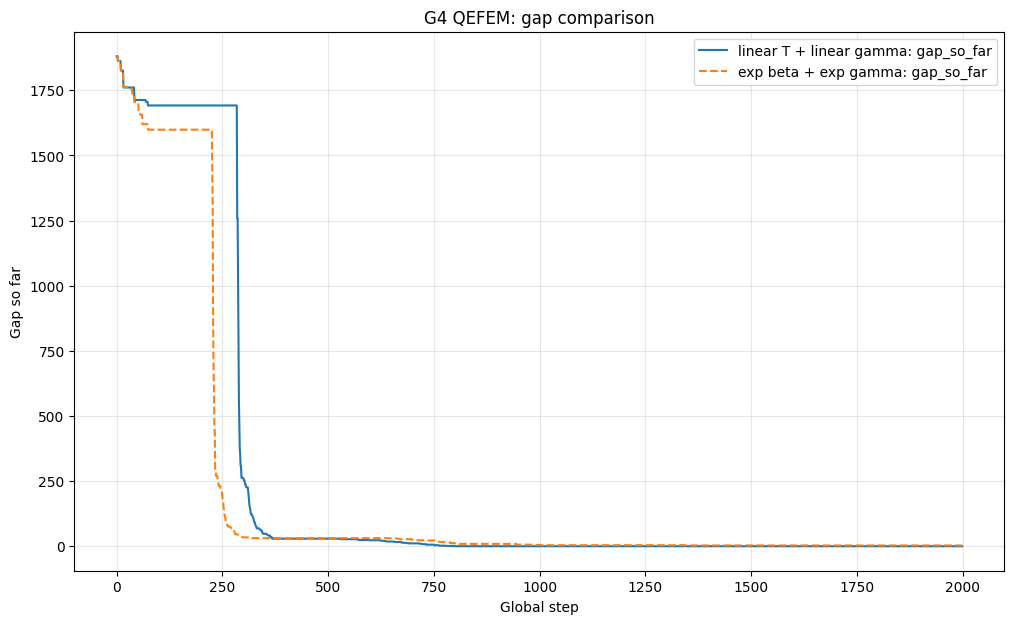

In [27]:
compare_histories(
    history_g4_lin,
    history_g4_exp,
    y_cols=["gap_so_far"],
    labels=(label_1, label_2),
    title="G4 QEFEM: gap comparison",
    ylabel="Gap so far",
)

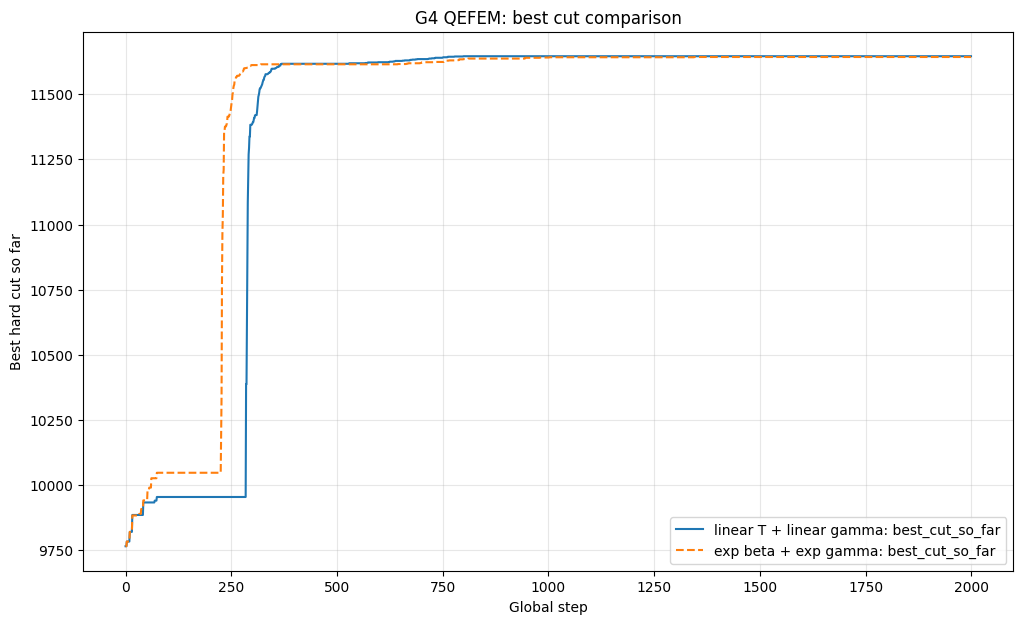

In [28]:
compare_histories(
    history_g4_lin,
    history_g4_exp,
    y_cols=["best_cut_so_far"],
    labels=(label_1, label_2),
    title="G4 QEFEM: best cut comparison",
    ylabel="Best hard cut so far",
)

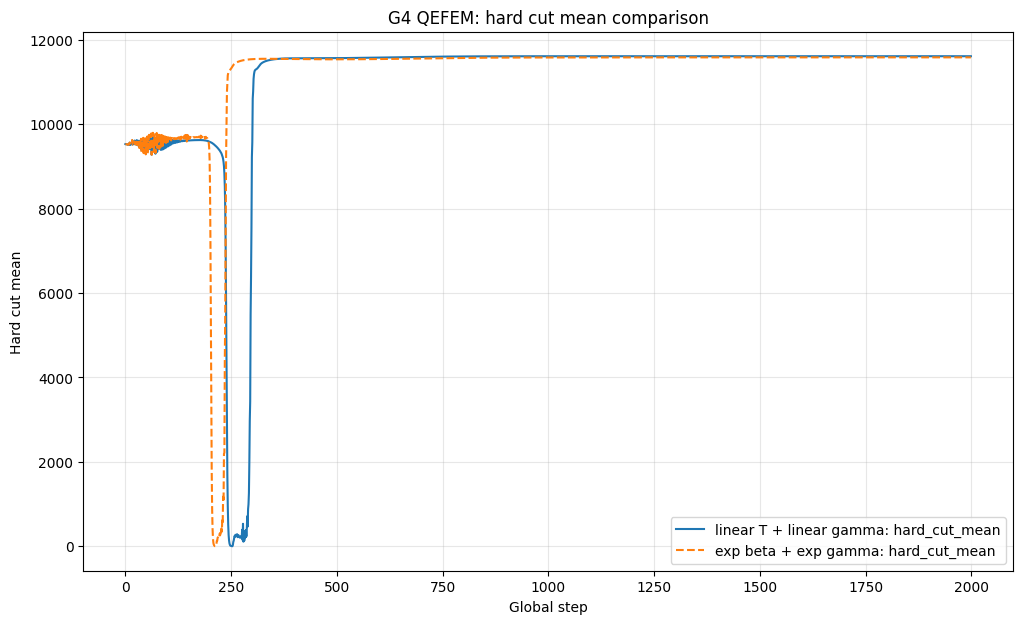

In [29]:
compare_histories(
    history_g4_lin,
    history_g4_exp,
    y_cols=["hard_cut_mean"],
    labels=(label_1, label_2),
    title="G4 QEFEM: hard cut mean comparison",
    ylabel="Hard cut mean",
)

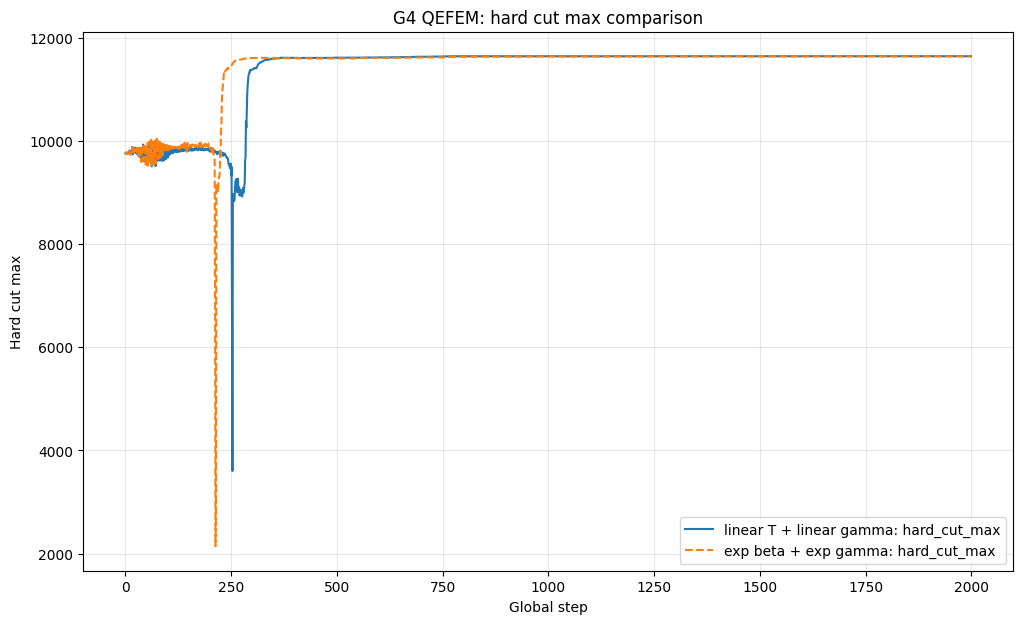

In [30]:
compare_histories(
    history_g4_lin,
    history_g4_exp,
    y_cols=["hard_cut_max"],
    labels=(label_1, label_2),
    title="G4 QEFEM: hard cut max comparison",
    ylabel="Hard cut max",
)

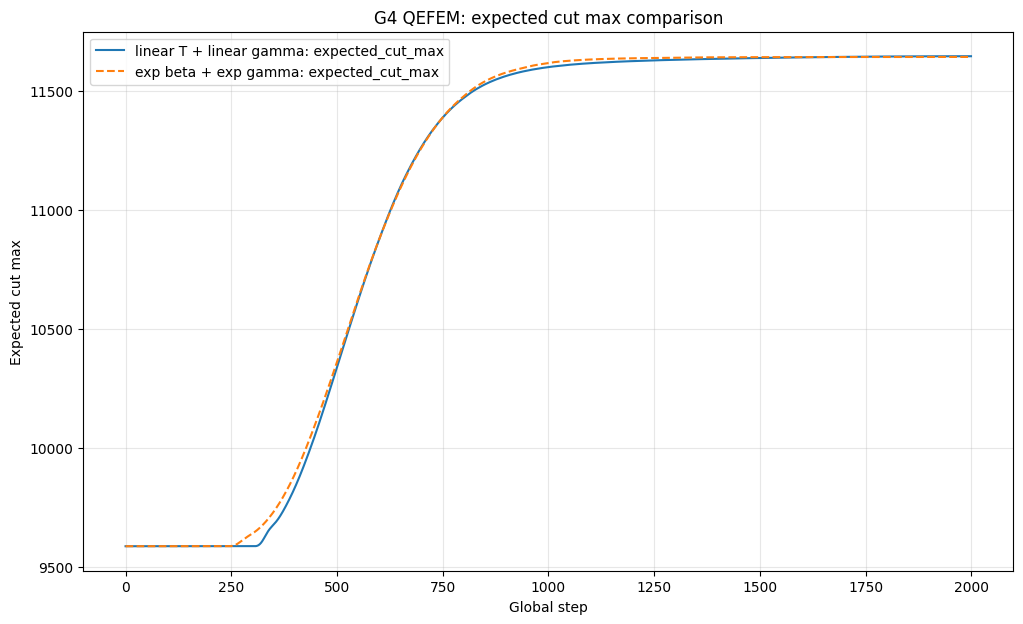

In [31]:
compare_histories(
    history_g4_lin,
    history_g4_exp,
    y_cols=["expected_cut_max"],
    labels=(label_1, label_2),
    title="G4 QEFEM: expected cut max comparison",
    ylabel="Expected cut max",
)

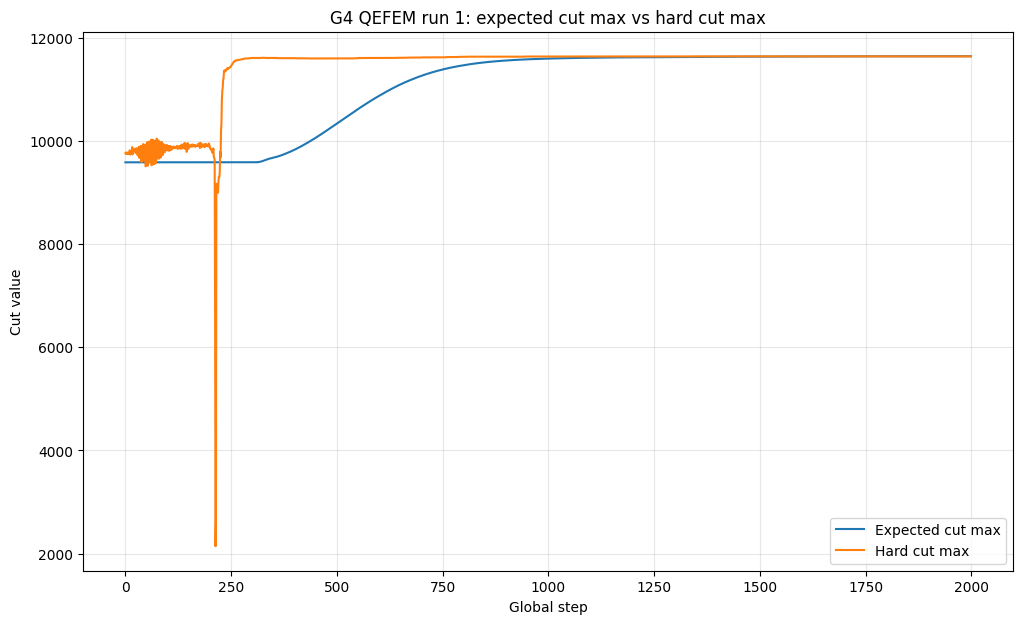

In [32]:
plt.figure(figsize=(12, 7))

plt.plot(
    history_g4_lin["global_step"],
    history_g4_lin["expected_cut_max"],
    label="Expected cut max",
)

plt.plot(
    history_g4_exp["global_step"],
    history_g4_exp["hard_cut_max"],
    label="Hard cut max",
)

plt.xlabel("Global step")
plt.ylabel("Cut value")
plt.title("G4 QEFEM run 1: expected cut max vs hard cut max")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

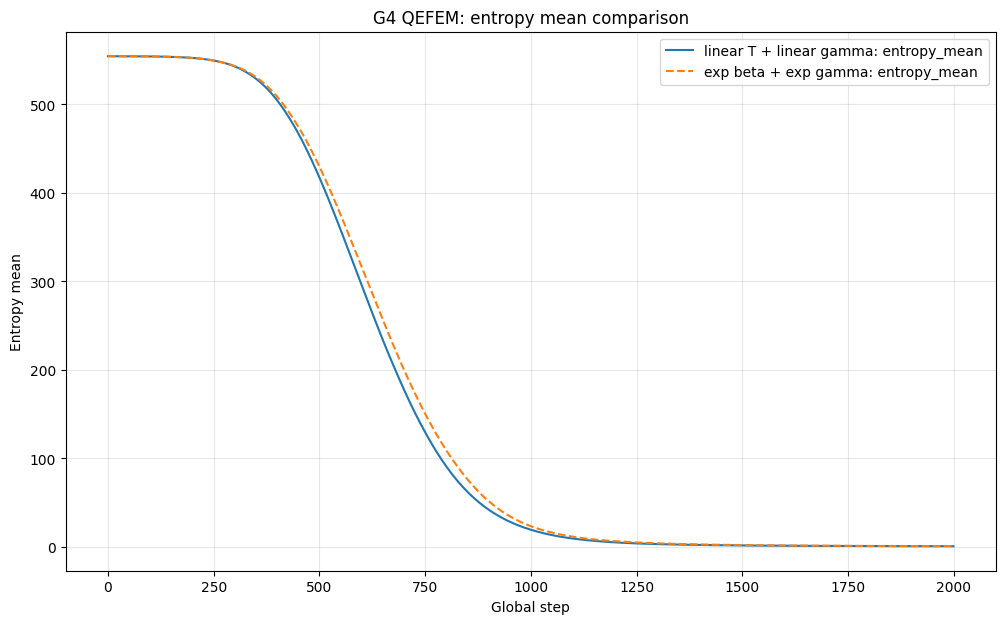

In [33]:
compare_histories(
    history_g4_lin,
    history_g4_exp,
    y_cols=["entropy_mean"],
    labels=(label_1, label_2),
    title="G4 QEFEM: entropy mean comparison",
    ylabel="Entropy mean",
)

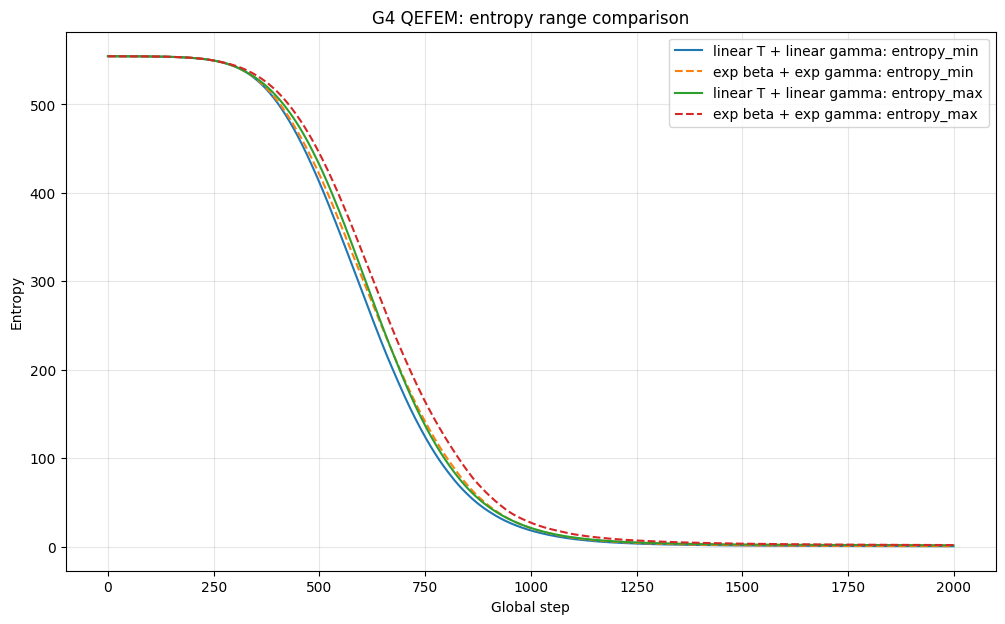

In [34]:
compare_histories(
    history_g4_lin,
    history_g4_exp,
    y_cols=["entropy_min", "entropy_max"],
    labels=(label_1, label_2),
    title="G4 QEFEM: entropy range comparison",
    ylabel="Entropy",
)

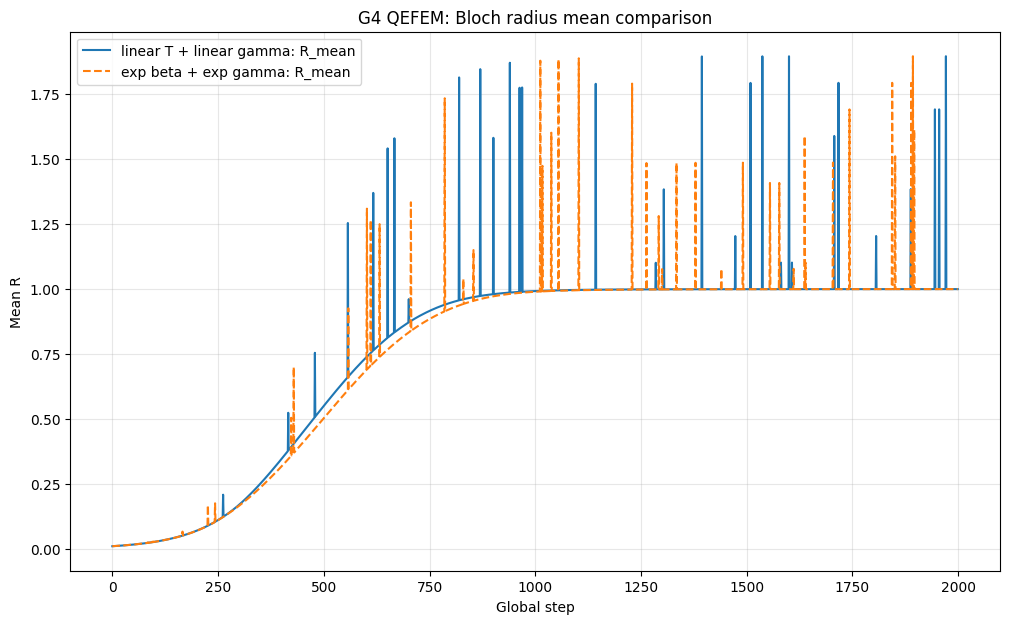

In [35]:
compare_histories(
    history_g4_lin,
    history_g4_exp,
    y_cols=["R_mean"],
    labels=(label_1, label_2),
    title="G4 QEFEM: Bloch radius mean comparison",
    ylabel="Mean R",
)

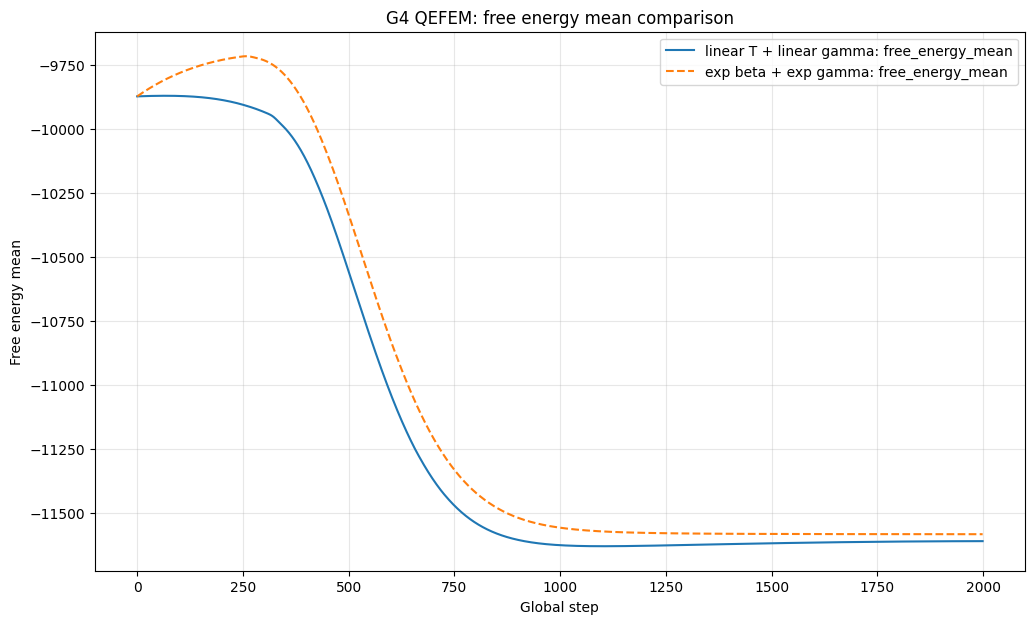

In [36]:
compare_histories(
    history_g4_lin,
    history_g4_exp,
    y_cols=["free_energy_mean"],
    labels=(label_1, label_2),
    title="G4 QEFEM: free energy mean comparison",
    ylabel="Free energy mean",
)

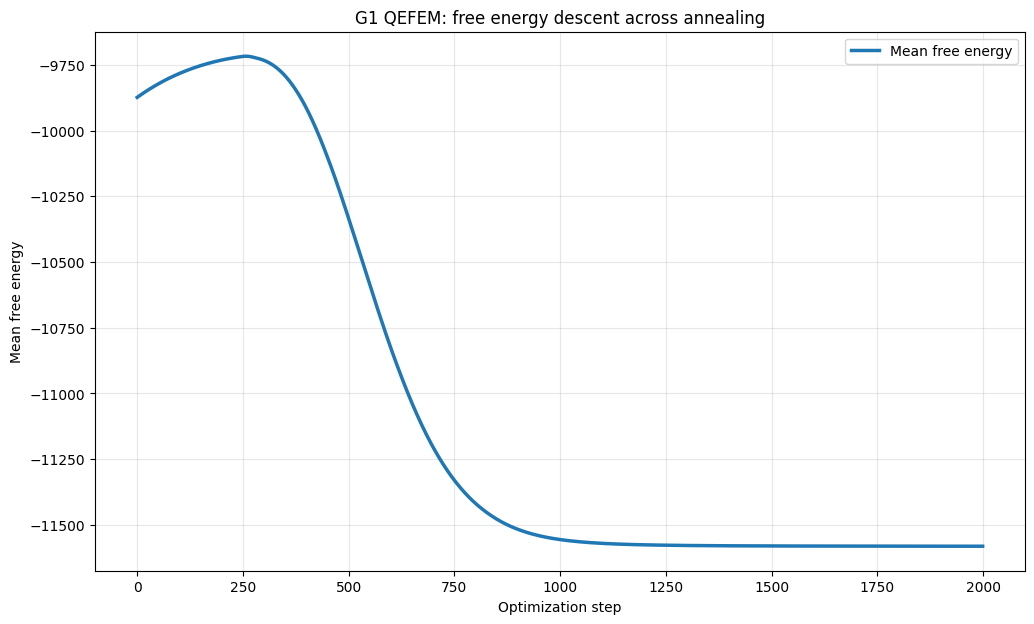

In [37]:
plt.figure(figsize=(12, 7))

plt.plot(
    history_g4_exp["global_step"],
    history_g4_exp["free_energy_mean"],
    linewidth=2.5,
    label="Mean free energy",
)

plt.xlabel("Optimization step")
plt.ylabel("Mean free energy")
plt.title("G1 QEFEM: free energy descent across annealing")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

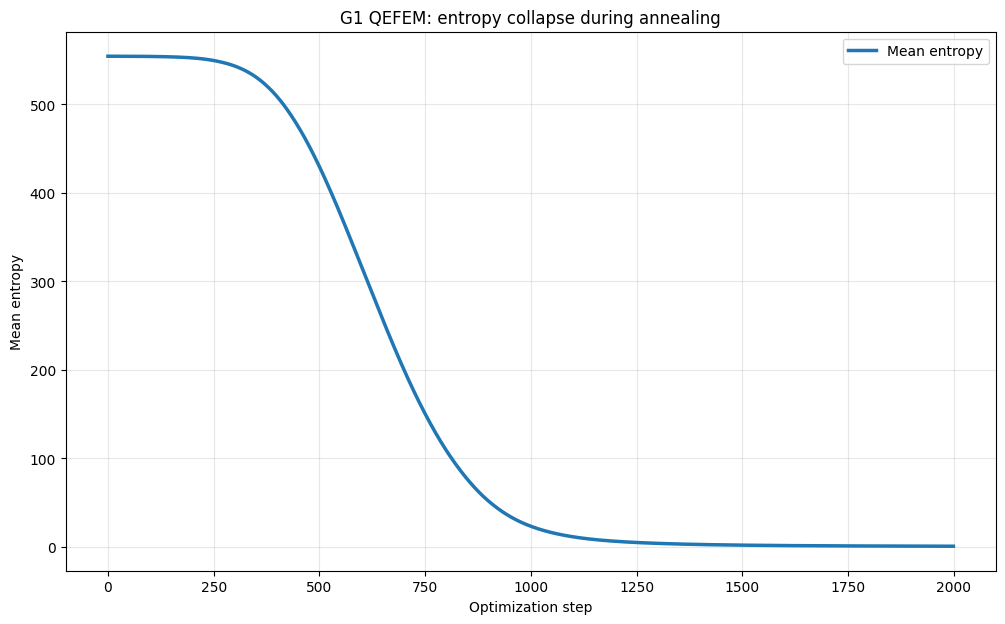

In [38]:
plt.figure(figsize=(12, 7))

plt.plot(
    history_g4_exp["global_step"],
    history_g4_exp["entropy_mean"],
    linewidth=2.5,
    label="Mean entropy",
)

plt.xlabel("Optimization step")
plt.ylabel("Mean entropy")
plt.title("G1 QEFEM: entropy collapse during annealing")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [50]:
bad = history_g4_lin.loc[history_g4_lin["R_mean"] > 1]

print(bad[[
    "global_step",
    "R_mean",
    "R_min",
    "R_max",
    "rx_abs_mean",
    "rz_abs_mean"
]])

      global_step    R_mean     R_min     R_max  rx_abs_mean  rz_abs_mean
557           557  1.254187  0.383778  0.908773     0.159487     0.627303
617           617  1.370062  0.427848  0.943772     0.162133     0.732113
651           651  1.541418  0.459354  0.957142     0.163985     0.782020
667           667  1.580259  0.476167  0.962257     0.164743     0.802787
820           820  1.814492  0.716795  0.989624     0.163647     0.929585
870           870  1.846321  0.798650  0.993458     0.159692     0.947771
901           901  1.582083  0.839266  0.995077     0.156698     0.955557
940           940  1.871020  0.878313  0.996644     0.152555     0.962753
963           963  1.774804  0.895820  0.997321     0.149973     0.966001
969           969  1.775860  0.899815  0.997474     0.149288     0.966751
1143         1143  1.789966  0.954526  0.999479     0.127938     0.979124
1285         1285  1.101092  0.962737  0.999804     0.109288     0.983901
1304         1304  1.383803  0.963106 

In [48]:
def clean_bloch_history(h):
    h = h.copy()

    # Keep the final record if the same global step was logged repeatedly
    h = (
        h.sort_values("global_step")
         .drop_duplicates(subset="global_step", keep="last")
    )

    # Remove physically invalid diagnostic rows
    valid = (
        h["R_mean"].between(0, 1)
        & h["R_min"].between(0, 1)
        & h["R_max"].between(0, 1)
        & h["rx_abs_mean"].between(0, 1)
        & h["rz_abs_mean"].between(0, 1)
    )

    return h.loc[valid].reset_index(drop=True)


history_g4_lin_clean = clean_bloch_history(history_g4_lin)
history_g4_exp_clean = clean_bloch_history(history_g4_exp)

<>:9: SyntaxWarning: invalid escape sequence '\G'
<>:10: SyntaxWarning: invalid escape sequence '\G'
<>:9: SyntaxWarning: invalid escape sequence '\G'
<>:10: SyntaxWarning: invalid escape sequence '\G'
/var/folders/hs/wzcwdwgd39lbf4_c_gqzw19r0000gn/T/ipykernel_8512/2400004725.py:9: SyntaxWarning: invalid escape sequence '\G'
  label_lin = "Linear T + Linear $\Gamma$"
/var/folders/hs/wzcwdwgd39lbf4_c_gqzw19r0000gn/T/ipykernel_8512/2400004725.py:10: SyntaxWarning: invalid escape sequence '\G'
  label_exp = "Exponential $\\beta$ + Exponential $\Gamma$"


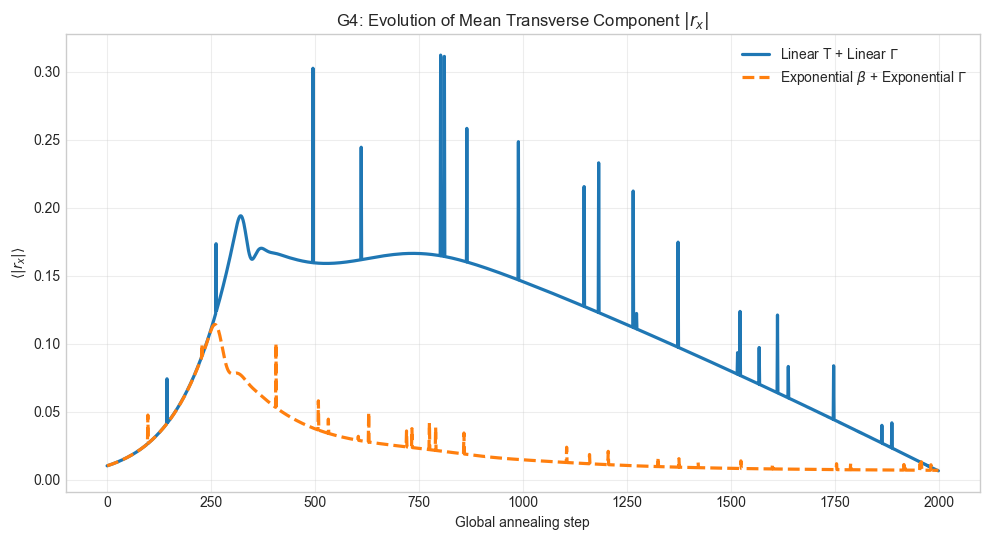

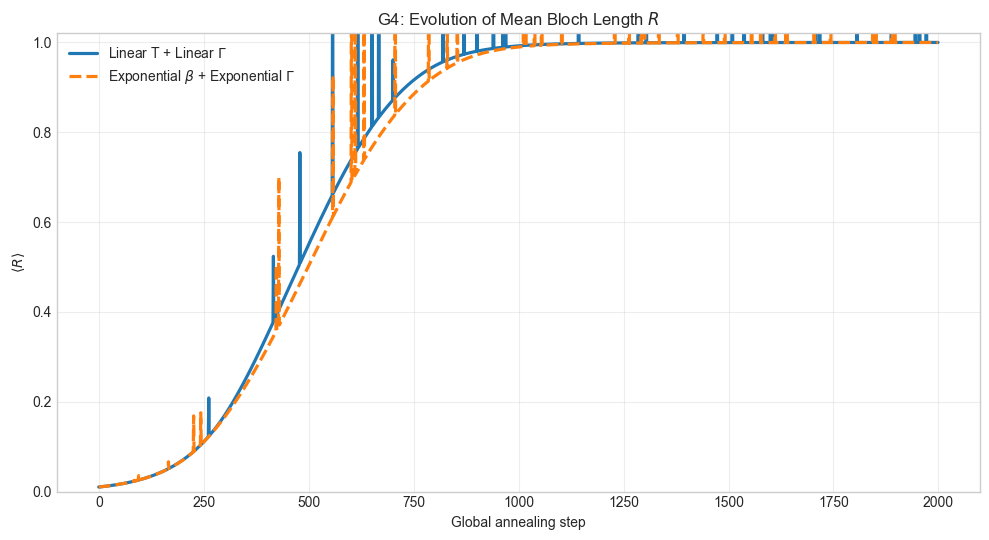

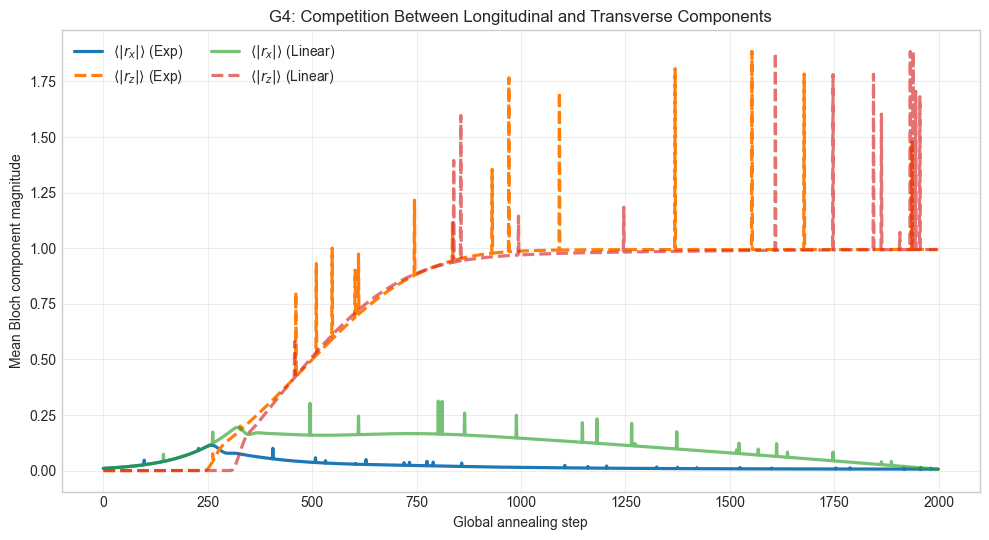

Saved plots to:
/Users/ronit/Desktop/QeFEM/main/maxcut_results/v2/presentation_plots


In [49]:
import matplotlib.pyplot as plt
from pathlib import Path

plt.style.use("seaborn-v0_8-whitegrid")

OUT_DIR = Path.home() / "Desktop/QeFEM/main/maxcut_results/v2/presentation_plots"
OUT_DIR.mkdir(parents=True, exist_ok=True)

label_lin = "Linear T + Linear $\Gamma$"
label_exp = "Exponential $\\beta$ + Exponential $\Gamma$"

step_lin = history_g4_lin["global_step"]
step_exp = history_g4_exp["global_step"]

R_lin  = history_g4_lin["R_mean"]
R_exp  = history_g4_exp["R_mean"]

rx_lin = history_g4_lin["rx_abs_mean"]
rx_exp = history_g4_exp["rx_abs_mean"]

rz_lin = history_g4_lin["rz_abs_mean"]
rz_exp = history_g4_exp["rz_abs_mean"]


# ============================================================
# 1. Mean transverse coherence |rx|
# ============================================================
fig, ax = plt.subplots(figsize=(10,5.5))

ax.plot(
    step_lin,
    rx_lin,
    lw=2.3,
    label=label_lin
)

ax.plot(
    step_exp,
    rx_exp,
    "--",
    lw=2.3,
    label=label_exp
)

ax.set_title(r"G4: Evolution of Mean Transverse Component $|r_x|$")
ax.set_xlabel("Global annealing step")
ax.set_ylabel(r"$\langle |r_x| \rangle$")
ax.grid(alpha=0.35)
ax.legend()

plt.tight_layout()
plt.savefig(OUT_DIR/"g4_rx_lin_vs_exp.pdf")
plt.savefig(OUT_DIR/"g4_rx_lin_vs_exp.png",dpi=300)
plt.show()


# ============================================================
# 2. Mean Bloch length (Purity)
# ============================================================
fig, ax = plt.subplots(figsize=(10,5.5))

ax.plot(
    step_lin,
    R_lin,
    lw=2.3,
    label=label_lin
)

ax.plot(
    step_exp,
    R_exp,
    "--",
    lw=2.3,
    label=label_exp
)

ax.set_title(r"G4: Evolution of Mean Bloch Length $R$")
ax.set_xlabel("Global annealing step")
ax.set_ylabel(r"$\langle R\rangle$")
ax.set_ylim(0,1.02)
ax.grid(alpha=0.35)
ax.legend()

plt.tight_layout()
plt.savefig(OUT_DIR/"g4_R_lin_vs_exp.pdf")
plt.savefig(OUT_DIR/"g4_R_lin_vs_exp.png",dpi=300)
plt.show()


# ============================================================
# 3. Competition between |rx| and |rz|
# ============================================================
fig, ax = plt.subplots(figsize=(10,5.5))

ax.plot(
    step_exp,
    rx_exp,
    lw=2.3,
    label=r"$\langle |r_x| \rangle$ (Exp)"
)

ax.plot(
    step_exp,
    rz_exp,
    "--",
    lw=2.3,
    label=r"$\langle |r_z| \rangle$ (Exp)"
)

ax.plot(
    step_lin,
    rx_lin,
    lw=2.3,
    alpha=0.65,
    label=r"$\langle |r_x| \rangle$ (Linear)"
)

ax.plot(
    step_lin,
    rz_lin,
    "--",
    lw=2.3,
    alpha=0.65,
    label=r"$\langle |r_z| \rangle$ (Linear)"
)

ax.set_title(r"G4: Competition Between Longitudinal and Transverse Components")
ax.set_xlabel("Global annealing step")
ax.set_ylabel("Mean Bloch component magnitude")
ax.grid(alpha=0.35)
ax.legend(ncol=2)

plt.tight_layout()
plt.savefig(OUT_DIR/"g4_rx_rz_lin_vs_exp.pdf")
plt.savefig(OUT_DIR/"g4_rx_rz_lin_vs_exp.png",dpi=300)
plt.show()

print(f"Saved plots to:\n{OUT_DIR}")

In [43]:
history_g4_exp.columns

Index(['graph_name', 'optimizer', 'gradient_mode', 'grad_type', 'outer_rep',
       'step', 'global_step', 'beta', 'gamma', 'free_energy_mean',
       'free_energy_min', 'free_energy_max', 'expected_cut_mean',
       'expected_cut_max', 'expected_cut_min', 'hard_cut_mean', 'hard_cut_max',
       'hard_cut_min', 'best_cut_so_far', 'best_known_cut', 'gap_so_far',
       'accuracy_so_far', 'best_replica_in_batch', 'best_replica_so_far',
       'best_outer_rep_so_far', 'best_step_so_far', 'entropy_mean',
       'entropy_min', 'entropy_max', 'R_mean', 'R_min', 'R_max', 'rx_abs_mean',
       'rz_abs_mean', 'grad_norm_before_clip', 'grad_norm_after_clip',
       'rep_elapsed_sec', 'elapsed_sec'],
      dtype='object')

In [44]:
history_g4_exp.iloc[500]

graph_name                         G4
optimizer                        adam
gradient_mode                    auto
grad_type                        auto
outer_rep                           0
step                              500
global_step                       500
beta                        17.802244
gamma                        0.177674
free_energy_mean        -10334.055664
free_energy_min         -10390.738281
free_energy_max         -10238.578125
expected_cut_mean        10304.607422
expected_cut_max         10361.857422
expected_cut_min         10208.022461
hard_cut_mean            11535.517578
hard_cut_max                  11604.0
hard_cut_min                  11433.0
best_cut_so_far               11615.0
best_known_cut                11646.0
gap_so_far                       31.0
accuracy_so_far              0.997338
best_replica_in_batch            1954
best_replica_so_far              1398
best_outer_rep_so_far               0
best_step_so_far                  320
entropy_mean

In [46]:
history_g4_exp[
[
"R_mean",
"R_min",
"R_max",
"rx_abs_mean",
"rz_abs_mean"
]
].head(20)

,R_mean,R_min,R_max,rx_abs_mean,rz_abs_mean
0,0.010099,0.010048,0.010151,0.010099,0.000085
1,0.010200,0.010148,0.010252,0.010200,0.000020
2,0.010301,0.010249,0.010354,0.010301,0.000046
3,0.010404,0.010351,0.010457,0.010404,0.000066
4,0.010507,0.010454,0.010561,0.010507,0.000051
5,0.010612,0.010558,0.010666,0.010612,0.000020
6,0.010717,0.010663,0.010772,0.010717,0.000019
7,0.010824,0.010769,0.010879,0.010824,0.000043
8,0.010931,0.010876,0.010987,0.010931,0.000050
9,0.011040,0.010984,0.011097,0.011040,0.000039


In [47]:
cols = ["global_step", "R_mean", "R_min", "R_max", "rx_abs_mean", "rz_abs_mean"]

for name, h in [
    ("linear", history_g4_lin),
    ("exponential", history_g4_exp),
]:
    print(f"\n{name.upper()}")
    print(h[cols].describe())

    print("\nDuplicate global steps:")
    print(h.loc[h["global_step"].duplicated(keep=False), cols].head(30))

    print("\nUnphysical rows:")
    bad = h[
        (h["R_mean"] > 1)
        | (h["R_min"] > 1)
        | (h["R_max"] > 1)
        | (h["rx_abs_mean"] > 1)
        | (h["rz_abs_mean"] > 1)
    ]
    display(bad[cols])


LINEAR
       global_step       R_mean        R_min        R_max  rx_abs_mean  \
count  2000.000000  2000.000000  2000.000000  2000.000000  2000.000000   
mean    999.500000     0.767847     0.670716     0.803141     0.105721   
std     577.494589     0.370269     0.352171     0.349748     0.055442   
min       0.000000     0.010099     0.010048     0.010151     0.006429   
25%     499.750000     0.551630     0.349490     0.850454     0.055109   
50%     999.500000     0.992821     0.916937     0.998116     0.114154   
75%    1499.250000     0.999478     0.964294     0.999928     0.159881   
max    1999.000000     1.896135     0.965675     0.999980     0.312392   

        rz_abs_mean  
count  2.000000e+03  
mean   7.337265e-01  
std    3.846753e-01  
min    7.449655e-09  
25%    5.126297e-01  
50%    9.703462e-01  
75%    9.889105e-01  
max    1.884578e+00  

Duplicate global steps:
Empty DataFrame
Columns: [global_step, R_mean, R_min, R_max, rx_abs_mean, rz_abs_mean]
Index: []

Unph

,global_step,R_mean,R_min,R_max,rx_abs_mean,rz_abs_mean
557,557,1.254187,0.383778,0.908773,0.159487,0.627303
617,617,1.370062,0.427848,0.943772,0.162133,0.732113
651,651,1.541418,0.459354,0.957142,0.163985,0.782020
667,667,1.580259,0.476167,0.962257,0.164743,0.802787
820,820,1.814492,0.716795,0.989624,0.163647,0.929585
839,839,0.964013,0.749827,0.991284,0.162303,1.394467
856,856,0.969538,0.777511,0.992552,0.160928,1.596447
870,870,1.846321,0.798650,0.993458,0.159692,0.947771
901,901,1.582083,0.839266,0.995077,0.156698,0.955557
940,940,1.871020,0.878313,0.996644,0.152555,0.962753



EXPONENTIAL
       global_step       R_mean        R_min        R_max  rx_abs_mean  \
count  2000.000000  2000.000000  2000.000000  2000.000000  2000.000000   
mean    999.500000     0.757622     0.479042     0.813014     0.023948   
std     577.494589     0.371264     0.344329     0.338822     0.023059   
min       0.000000     0.010099     0.010048     0.010151     0.006785   
25%     499.750000     0.504773     0.189398     0.858405     0.008310   
50%     999.500000     0.990152     0.314031     0.997633     0.013970   
75%    1499.250000     0.999317     0.894154     0.999890     0.029098   
max    1999.000000     1.896040     0.930033     0.999973     0.114097   

        rz_abs_mean  
count  2.000000e+03  
mean   7.414868e-01  
std    3.764657e-01  
min    1.285487e-08  
25%    5.007215e-01  
50%    9.876218e-01  
75%    9.938959e-01  
max    1.885165e+00  

Duplicate global steps:
Empty DataFrame
Columns: [global_step, R_mean, R_min, R_max, rx_abs_mean, rz_abs_mean]
Index: []


,global_step,R_mean,R_min,R_max,rx_abs_mean,rz_abs_mean
548,548,0.594123,0.193353,0.899406,0.032611,1.000926
602,602,1.309347,0.197713,0.930499,0.028973,0.688242
611,611,1.265344,0.198482,0.934637,0.028489,0.973948
632,632,1.249749,0.200289,0.943454,0.027464,0.736618
706,706,1.333885,0.207787,0.966669,0.024541,0.837091
745,745,0.879903,0.213001,0.975102,0.023126,1.216143
786,786,1.734294,0.220067,0.982024,0.021589,0.912433
830,830,1.039083,0.229355,0.987935,0.019919,0.940736
836,836,0.945889,0.230867,0.988618,0.019688,1.114468
854,854,1.150072,0.235834,0.990442,0.018983,0.952855


Removed/interpolated 41 corrupted rows.
Removed/interpolated 53 corrupted rows.


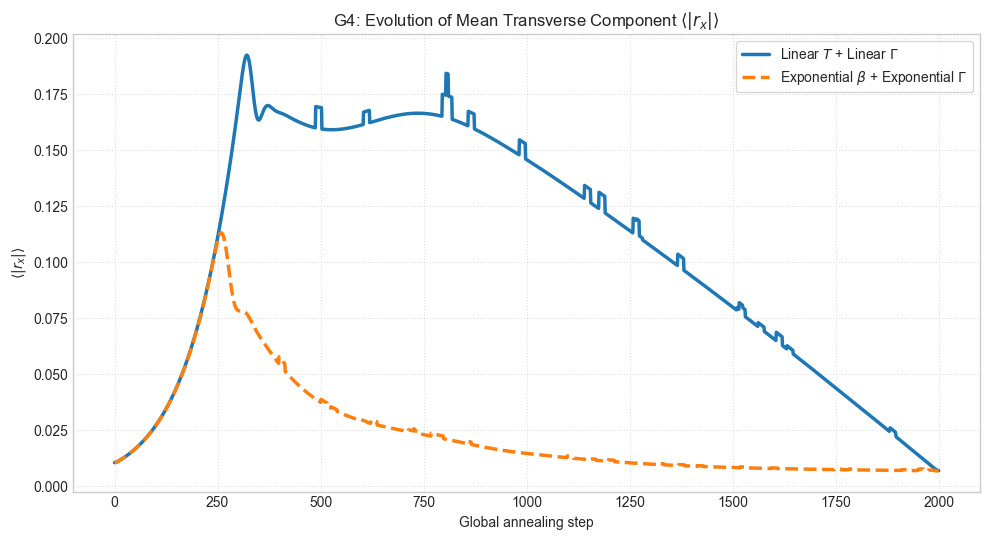

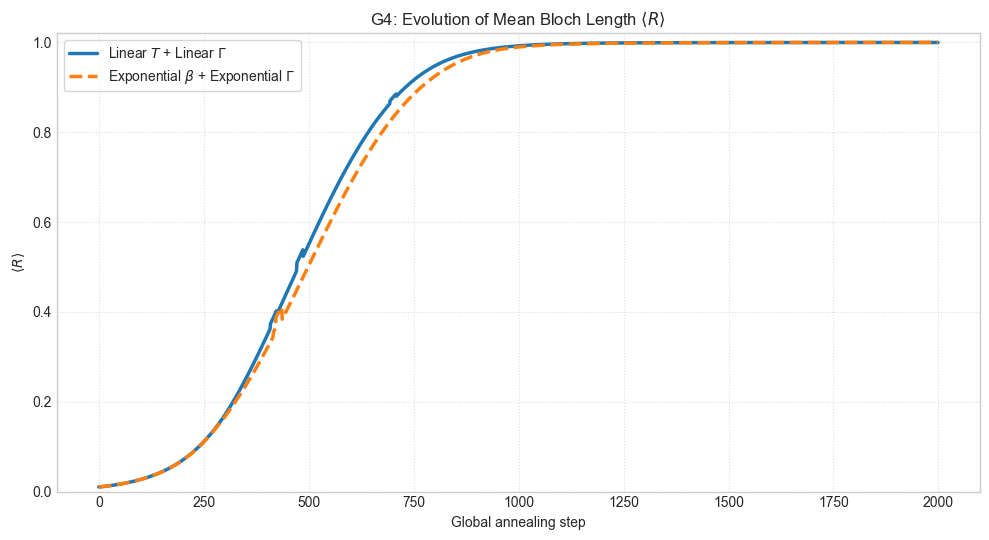

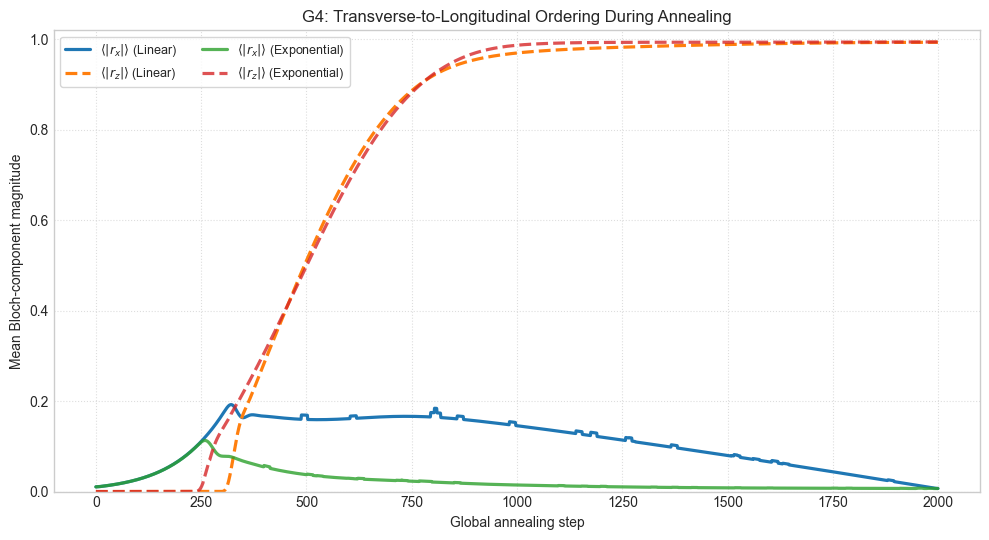

Saved cleaned presentation plots to:
/Users/ronit/Desktop/QeFEM/main/maxcut_results/v2/presentation_plots


In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

plt.style.use("seaborn-v0_8-whitegrid")

OUT_DIR = Path.home() / "Desktop/QeFEM/main/maxcut_results/v2/presentation_plots"
OUT_DIR.mkdir(parents=True, exist_ok=True)

label_lin = r"Linear $T$ + Linear $\Gamma$"
label_exp = r"Exponential $\beta$ + Exponential $\Gamma$"


def clean_bloch_history(history, smooth_window=15):
    h = history.copy().sort_values("global_step").reset_index(drop=True)

    # Physical consistency conditions
    valid = (
        h["R_min"].between(0.0, 1.0)
        & h["R_max"].between(0.0, 1.0)
        & h["R_mean"].between(0.0, 1.0)
        & (h["R_mean"] >= h["R_min"])
        & (h["R_mean"] <= h["R_max"])
        & h["rx_abs_mean"].between(0.0, 1.0)
        & h["rz_abs_mean"].between(0.0, 1.0)
        & (h["rx_abs_mean"] <= h["R_mean"] + 1e-8)
        & (h["rz_abs_mean"] <= h["R_mean"] + 1e-8)
    )

    bad_count = (~valid).sum()

    # Replace corrupted diagnostics by NaN
    cols = ["R_mean", "rx_abs_mean", "rz_abs_mean"]
    h.loc[~valid, cols] = np.nan

    # Interpolate only across the sparse corrupted rows
    h[cols] = h[cols].interpolate(
        method="linear",
        limit_direction="both"
    )

    # Light smoothing for presentation
    for col in cols:
        h[f"{col}_smooth"] = (
            h[col]
            .rolling(
                window=smooth_window,
                center=True,
                min_periods=1
            )
            .mean()
        )

    print(f"Removed/interpolated {bad_count} corrupted rows.")
    return h


lin_clean = clean_bloch_history(history_g4_lin, smooth_window=15)
exp_clean = clean_bloch_history(history_g4_exp, smooth_window=15)


# ============================================================
# 1. Transverse component
# ============================================================
fig, ax = plt.subplots(figsize=(10, 5.5))

ax.plot(
    lin_clean["global_step"],
    lin_clean["rx_abs_mean_smooth"],
    linewidth=2.5,
    label=label_lin
)

ax.plot(
    exp_clean["global_step"],
    exp_clean["rx_abs_mean_smooth"],
    linewidth=2.5,
    linestyle="--",
    label=label_exp
)

ax.set_title(r"G4: Evolution of Mean Transverse Component $\langle |r_x| \rangle$")
ax.set_xlabel("Global annealing step")
ax.set_ylabel(r"$\langle |r_x| \rangle$")
ax.grid(True, linestyle=":", alpha=0.65)
ax.legend(frameon=True)

fig.tight_layout()
fig.savefig(OUT_DIR / "g4_rx_lin_vs_exp_clean.pdf", bbox_inches="tight")
fig.savefig(OUT_DIR / "g4_rx_lin_vs_exp_clean.png", dpi=300, bbox_inches="tight")
plt.show()


# ============================================================
# 2. Mean Bloch length
# ============================================================
fig, ax = plt.subplots(figsize=(10, 5.5))

ax.plot(
    lin_clean["global_step"],
    lin_clean["R_mean_smooth"],
    linewidth=2.5,
    label=label_lin
)

ax.plot(
    exp_clean["global_step"],
    exp_clean["R_mean_smooth"],
    linewidth=2.5,
    linestyle="--",
    label=label_exp
)

ax.set_title(r"G4: Evolution of Mean Bloch Length $\langle R\rangle$")
ax.set_xlabel("Global annealing step")
ax.set_ylabel(r"$\langle R\rangle$")
ax.set_ylim(0.0, 1.02)
ax.grid(True, linestyle=":", alpha=0.65)
ax.legend(frameon=True)

fig.tight_layout()
fig.savefig(OUT_DIR / "g4_R_lin_vs_exp_clean.pdf", bbox_inches="tight")
fig.savefig(OUT_DIR / "g4_R_lin_vs_exp_clean.png", dpi=300, bbox_inches="tight")
plt.show()


# ============================================================
# 3. Longitudinal versus transverse ordering
# ============================================================
fig, ax = plt.subplots(figsize=(10, 5.5))

ax.plot(
    lin_clean["global_step"],
    lin_clean["rx_abs_mean_smooth"],
    linewidth=2.3,
    label=r"$\langle |r_x| \rangle$ (Linear)"
)

ax.plot(
    lin_clean["global_step"],
    lin_clean["rz_abs_mean_smooth"],
    linewidth=2.3,
    linestyle="--",
    label=r"$\langle |r_z| \rangle$ (Linear)"
)

ax.plot(
    exp_clean["global_step"],
    exp_clean["rx_abs_mean_smooth"],
    linewidth=2.3,
    alpha=0.8,
    label=r"$\langle |r_x| \rangle$ (Exponential)"
)

ax.plot(
    exp_clean["global_step"],
    exp_clean["rz_abs_mean_smooth"],
    linewidth=2.3,
    linestyle="--",
    alpha=0.8,
    label=r"$\langle |r_z| \rangle$ (Exponential)"
)

ax.set_title("G4: Transverse-to-Longitudinal Ordering During Annealing")
ax.set_xlabel("Global annealing step")
ax.set_ylabel("Mean Bloch-component magnitude")
ax.set_ylim(0.0, 1.02)
ax.grid(True, linestyle=":", alpha=0.65)
ax.legend(frameon=True, ncol=2, fontsize=9)

fig.tight_layout()
fig.savefig(OUT_DIR / "g4_rx_rz_lin_vs_exp_clean.pdf", bbox_inches="tight")
fig.savefig(OUT_DIR / "g4_rx_rz_lin_vs_exp_clean.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"Saved cleaned presentation plots to:\n{OUT_DIR}")

In [37]:
import pickle
from pathlib import Path

OUT_DIR.mkdir(parents=True, exist_ok=True)

save_path = OUT_DIR / "G4_gap0_qefem_result.pkl"

with open(save_path, "wb") as f:
    pickle.dump(g4_result_lin, f)

print("Saved:", save_path)
print(g4_result_lin["summary"])

Saved: qefem_v2_res/G4_gap0_qefem_result.pkl
{'graph_name': 'G4', 'optimizer': 'adam', 'gradient_mode': 'auto', 'grad_type': 'auto', 'best_cut': 11646.0, 'best_known_cut': 11646.0, 'gap': 0.0, 'accuracy': 1.0, 'best_outer_rep': 0, 'best_replica': 8035, 'best_step': 783, 'n_batch': 10000, 'n_rep_completed': 1, 'n_rep_requested': 1, 'n_steps': 2000, 'total_replica_attempts_completed': 10000, 'T_max': 0.5, 'T_min': 8e-05, 'beta_schedule': 'linear_temperature', 'gamma_max': 1.0, 'gamma_min': 0.001, 'gamma_schedule': 'linear', 'lr': 0.01, 'grad_clip': 1.0, 'bloch_length_init': 0.01, 'field_noise': 0.001, 'theta_init': 1.5707963267948966, 'theta_noise': 0.001, 'rep_elapsed_sec': 176.54229879379272, 'elapsed_sec': 176.54235100746155, 'success': True}


### Checking if the same happens for increasing Replica number

In [38]:
g4_1 = get_gset_local_hparams(
    4,
    n_batch=2000,
    n_rep=1,
    n_steps=2000,
    optimizer="adam",
    lr=1e-2,
    grad_type="auto",
    grad_clip=1.0,
    T_max=0.5,
    T_min=8e-5,
    beta_schedule="linear_temperature",
    gamma_max=1.0,
    gamma_min=1e-3,
    gamma_schedule="linear",
)

g4_2 = get_gset_local_hparams(
    4,
    n_batch=5000,
    n_rep=1,
    n_steps=2000,
    optimizer="adam",
    lr=1e-2,
    grad_type="auto",
    grad_clip=1.0,
    T_max=0.5,
    T_min=8e-5,
    beta_schedule="linear_temperature",
    gamma_max=1.0,
    gamma_min=1e-3,
    gamma_schedule="linear",
)

g4_3 = get_gset_local_hparams(
    4,
    n_batch=10000,
    n_rep=1,
    n_steps=2000,
    optimizer="adam",
    lr=1e-2,
    grad_type="auto",
    grad_clip=1.0,
    T_max=0.5,
    T_min=8e-5,
    beta_schedule="linear_temperature",
    gamma_max=1.0,
    gamma_min=1e-3,
    gamma_schedule="linear",
)

g4_4 = get_gset_local_hparams(
    4,
    n_batch=12000,
    n_rep=1,
    n_steps=2000,
    optimizer="adam",
    lr=1e-2,
    grad_type="auto",
    grad_clip=1.0,
    T_max=0.5,
    T_min=8e-5,
    beta_schedule="linear_temperature",
    gamma_max=1.0,
    gamma_min=1e-3,
    gamma_schedule="linear",
)

g4_5 = get_gset_local_hparams(
    4,
    n_batch=15000,
    n_rep=1,
    n_steps=2000,
    optimizer="adam",
    lr=1e-2,
    grad_type="auto",
    grad_clip=1.0,
    T_max=0.5,
    T_min=8e-5,
    beta_schedule="linear_temperature",
    gamma_max=1.0,
    gamma_min=1e-3,
    gamma_schedule="linear",
)

In [39]:
g4_r1 = run_qefem_single_instance(
    W=W_G4,
    best_known_cut=11646,
    local_hparams=g4_1,
    seed=0,
    print_every=50,
)

Starting G4 | historical best = 11646 | optimizer = adam | gradient_mode = auto | n_batch = 2000 | n_rep = 1 | n_steps = 2000
G4 | rep: 1/1 | gap: 1897.0 | acc: 83.7111% | step: 1/2000 | beta: 2 | gamma: 1 | ecut: 9588.0 | hcut: 9749.0 | best: 9749.0 | S: 554.4769 | grad: 12.46->1 | rep_t 0.1s | total_t 0.1s
G4 | rep: 1/1 | gap: 1748.0 | acc: 84.9906% | step: 50/2000 | beta: 2.05 | gamma: 0.9755 | ecut: 9588.0 | hcut: 9621.0 | best: 9898.0 | S: 554.4104 | grad: 19.53->1 | rep_t 2.1s | total_t 2.1s
G4 | rep: 1/1 | gap: 1657.0 | acc: 85.7719% | step: 100/2000 | beta: 2.104 | gamma: 0.9505 | ecut: 9588.0 | hcut: 9853.0 | best: 9989.0 | S: 554.2320 | grad: 30.57->1 | rep_t 4.6s | total_t 4.6s
G4 | rep: 1/1 | gap: 1657.0 | acc: 85.7719% | step: 150/2000 | beta: 2.161 | gamma: 0.9255 | ecut: 9588.0 | hcut: 9854.0 | best: 9989.0 | S: 553.7673 | grad: 47.03->1 | rep_t 7.0s | total_t 7.0s
G4 | rep: 1/1 | gap: 1657.0 | acc: 85.7719% | step: 200/2000 | beta: 2.221 | gamma: 0.9005 | ecut: 9588.0 |

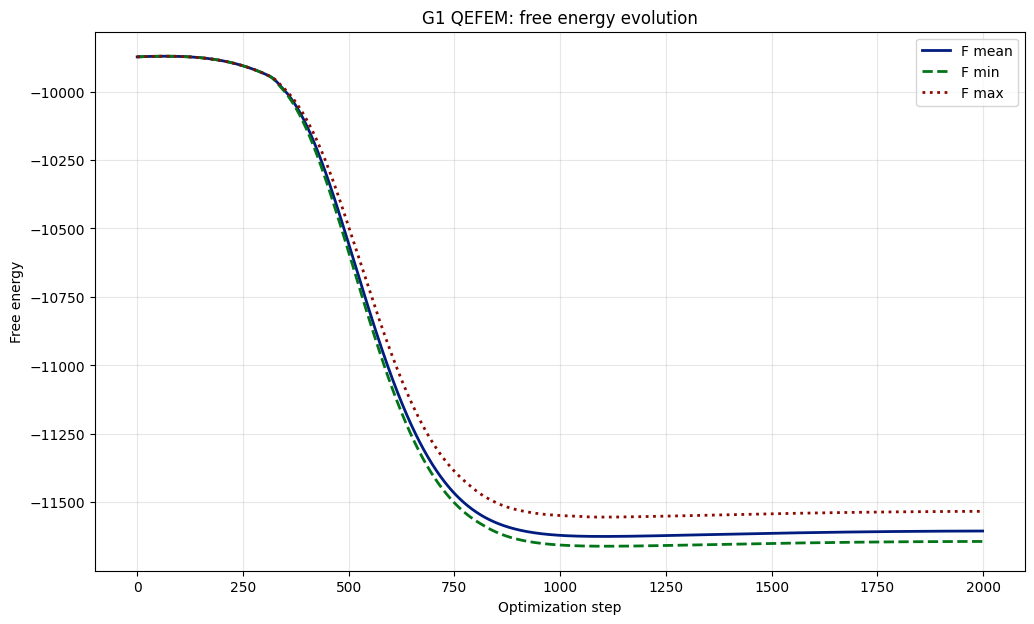

In [40]:
history_g1 = g4_r1["history"]

plt.style.use("seaborn-v0_8-dark-palette")

plt.figure(figsize=(12, 7))

plt.plot(
    history_g1["global_step"],
    history_g1["free_energy_mean"],
    label="F mean",
    linewidth=2,
)

plt.plot(
    history_g1["global_step"],
    history_g1["free_energy_min"],
    label="F min",
    linestyle="--",
    linewidth=2,
)

plt.plot(
    history_g1["global_step"],
    history_g1["free_energy_max"],
    label="F max",
    linestyle=":",
    linewidth=2,
)

plt.xlabel("Optimization step")
plt.ylabel("Free energy")
plt.title("G1 QEFEM: free energy evolution")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

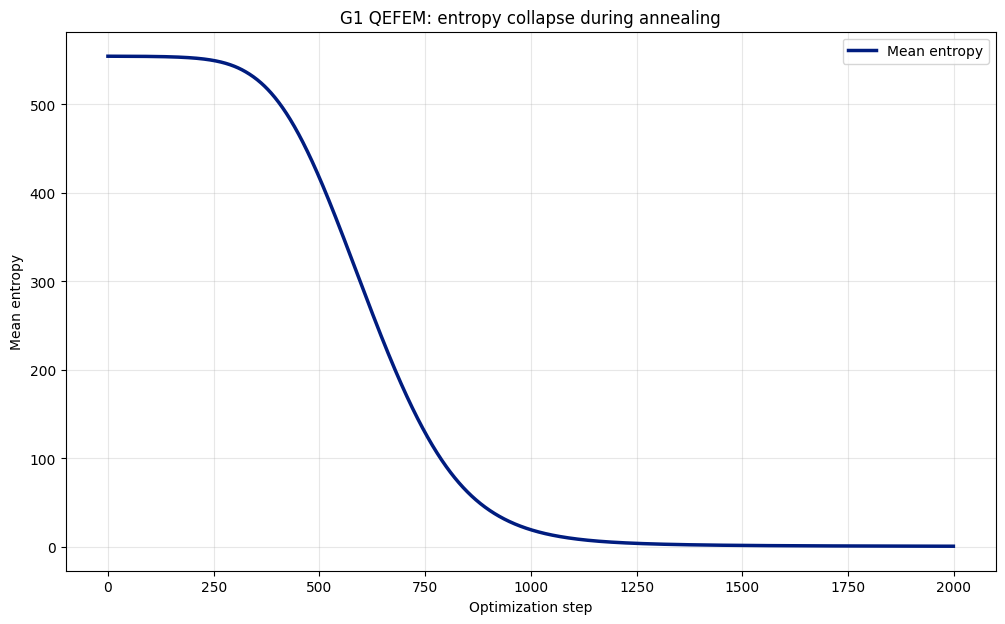

In [49]:
plt.figure(figsize=(12, 7))

plt.plot(
    history_g1["global_step"],
    history_g1["entropy_mean"],
    linewidth=2.5,
    label="Mean entropy",
)

plt.xlabel("Optimization step")
plt.ylabel("Mean entropy")
plt.title("G1 QEFEM: entropy collapse during annealing")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [96]:
g4_r2 = run_qefem_single_instance(
    W=W_G4,
    best_known_cut=11646,
    local_hparams=g4_2,
    seed=0,
    print_every=50,
)

Starting G4 | historical best = 11646 | optimizer = adam | gradient_mode = auto | n_batch = 5000 | n_rep = 1 | n_steps = 2000
G4 | rep: 1/1 | gap: 1881.0 | acc: 83.8485% | step: 1/2000 | beta: 2 | gamma: 1 | ecut: 9588.0 | hcut: 9765.0 | best: 9765.0 | S: 554.4769 | grad: 19.7->1 | rep_t 0.1s | total_t 0.1s
G4 | rep: 1/1 | gap: 1649.0 | acc: 85.8406% | step: 50/2000 | beta: 2.05 | gamma: 0.9755 | ecut: 9588.0 | hcut: 9709.0 | best: 9997.0 | S: 554.4104 | grad: 30.88->1 | rep_t 5.2s | total_t 5.2s
G4 | rep: 1/1 | gap: 1621.0 | acc: 86.0811% | step: 100/2000 | beta: 2.104 | gamma: 0.9505 | ecut: 9588.0 | hcut: 9933.0 | best: 10025.0 | S: 554.2321 | grad: 48.33->1 | rep_t 10.7s | total_t 10.7s
G4 | rep: 1/1 | gap: 1621.0 | acc: 86.0811% | step: 150/2000 | beta: 2.161 | gamma: 0.9255 | ecut: 9588.0 | hcut: 9844.0 | best: 10025.0 | S: 553.7672 | grad: 74.37->1 | rep_t 15.9s | total_t 15.9s
G4 | rep: 1/1 | gap: 1621.0 | acc: 86.0811% | step: 200/2000 | beta: 2.221 | gamma: 0.9005 | ecut: 958

In [97]:
g4_r3 = run_qefem_single_instance(
    W=W_G4,
    best_known_cut=11646,
    local_hparams=g4_3,
    seed=0,
    print_every=50,
)

Starting G4 | historical best = 11646 | optimizer = adam | gradient_mode = auto | n_batch = 10000 | n_rep = 1 | n_steps = 2000
G4 | rep: 1/1 | gap: 1881.0 | acc: 83.8485% | step: 1/2000 | beta: 2 | gamma: 1 | ecut: 9588.0 | hcut: 9765.0 | best: 9765.0 | S: 554.4769 | grad: 27.86->1 | rep_t 0.3s | total_t 0.3s
G4 | rep: 1/1 | gap: 1720.0 | acc: 85.2310% | step: 50/2000 | beta: 2.05 | gamma: 0.9755 | ecut: 9588.0 | hcut: 9742.0 | best: 9926.0 | S: 554.4104 | grad: 43.66->1 | rep_t 12.0s | total_t 12.0s
G4 | rep: 1/1 | gap: 1654.0 | acc: 85.7977% | step: 100/2000 | beta: 2.104 | gamma: 0.9505 | ecut: 9588.0 | hcut: 9867.0 | best: 9992.0 | S: 554.2321 | grad: 68.35->1 | rep_t 24.4s | total_t 24.4s
G4 | rep: 1/1 | gap: 1654.0 | acc: 85.7977% | step: 150/2000 | beta: 2.161 | gamma: 0.9255 | ecut: 9588.0 | hcut: 9879.0 | best: 9992.0 | S: 553.7670 | grad: 105.2->1 | rep_t 35.9s | total_t 35.9s
G4 | rep: 1/1 | gap: 1654.0 | acc: 85.7977% | step: 200/2000 | beta: 2.221 | gamma: 0.9005 | ecut: 9

In [98]:
g4_r4 = run_qefem_single_instance(
    W=W_G4,
    best_known_cut=11646,
    local_hparams=g4_4,
    seed=0,
    print_every=50,
)

Starting G4 | historical best = 11646 | optimizer = adam | gradient_mode = auto | n_batch = 12000 | n_rep = 1 | n_steps = 2000
G4 | rep: 1/1 | gap: 1881.0 | acc: 83.8485% | step: 1/2000 | beta: 2 | gamma: 1 | ecut: 9588.0 | hcut: 9765.0 | best: 9765.0 | S: 554.4769 | grad: 30.52->1 | rep_t 0.5s | total_t 0.5s
G4 | rep: 1/1 | gap: 1711.0 | acc: 85.3083% | step: 50/2000 | beta: 2.05 | gamma: 0.9755 | ecut: 9588.0 | hcut: 9740.0 | best: 9935.0 | S: 554.4104 | grad: 47.84->1 | rep_t 15.1s | total_t 15.1s
G4 | rep: 1/1 | gap: 1654.0 | acc: 85.7977% | step: 100/2000 | beta: 2.104 | gamma: 0.9505 | ecut: 9588.0 | hcut: 9879.0 | best: 9992.0 | S: 554.2321 | grad: 74.87->1 | rep_t 27.8s | total_t 27.8s
G4 | rep: 1/1 | gap: 1654.0 | acc: 85.7977% | step: 150/2000 | beta: 2.161 | gamma: 0.9255 | ecut: 9588.0 | hcut: 9889.0 | best: 9992.0 | S: 553.7673 | grad: 115.2->1 | rep_t 40.0s | total_t 40.0s
G4 | rep: 1/1 | gap: 1654.0 | acc: 85.7977% | step: 200/2000 | beta: 2.221 | gamma: 0.9005 | ecut: 9

In [99]:
g4_r5 = run_qefem_single_instance(
    W=W_G4,
    best_known_cut=11646,
    local_hparams=g4_5,
    seed=0,
    print_every=50,
)

Starting G4 | historical best = 11646 | optimizer = adam | gradient_mode = auto | n_batch = 15000 | n_rep = 1 | n_steps = 2000
G4 | rep: 1/1 | gap: 1881.0 | acc: 83.8485% | step: 1/2000 | beta: 2 | gamma: 1 | ecut: 9588.0 | hcut: 9765.0 | best: 9765.0 | S: 554.4769 | grad: 34.12->1 | rep_t 0.8s | total_t 0.8s
G4 | rep: 1/1 | gap: 1733.0 | acc: 85.1194% | step: 50/2000 | beta: 2.05 | gamma: 0.9755 | ecut: 9588.0 | hcut: 9730.0 | best: 9913.0 | S: 554.4104 | grad: 53.49->1 | rep_t 20.8s | total_t 20.8s
G4 | rep: 1/1 | gap: 1629.0 | acc: 86.0124% | step: 100/2000 | beta: 2.104 | gamma: 0.9505 | ecut: 9588.0 | hcut: 9847.0 | best: 10017.0 | S: 554.2321 | grad: 83.71->1 | rep_t 37.3s | total_t 37.3s
G4 | rep: 1/1 | gap: 1629.0 | acc: 86.0124% | step: 150/2000 | beta: 2.161 | gamma: 0.9255 | ecut: 9588.0 | hcut: 9849.0 | best: 10017.0 | S: 553.7673 | grad: 128.8->1 | rep_t 55.5s | total_t 55.5s
G4 | rep: 1/1 | gap: 1629.0 | acc: 86.0124% | step: 200/2000 | beta: 2.221 | gamma: 0.9005 | ecut:

In [100]:
g4_runs = {
    "n_batch=2000": g4_r1,
    "n_batch=5000": g4_r2,
    "n_batch=10000": g4_r3,
    "n_batch=12000": g4_r4,
    "n_batch=15000": g4_r5,
}


plt.style.use("seaborn-v0_8-dark-palette")


def plot_g4_batch_sweep(
    runs,
    y_col,
    ylabel,
    title,
    x_col="global_step",
    figsize=(12, 8),
):
    plt.figure(figsize=figsize)

    for label, result in runs.items():
        history = result["history"]

        if y_col not in history.columns:
            print(f"Skipping {label}: missing column {y_col}")
            continue

        plt.plot(
            history[x_col],
            history[y_col],
            label=label,
            linewidth=2,
        )

    plt.xlabel("Global step")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

In [101]:
def plot_accuracy_sweep(runs, figsize=(12, 8)):
    plt.figure(figsize=figsize)

    for label, result in runs.items():
        history = result["history"]

        plt.plot(
            history["global_step"],
            100.0 * history["accuracy_so_far"],
            label=label,
            linewidth=2,
        )

    plt.axhline(100.0, linestyle="--", linewidth=1.5, label="100%")
    plt.xlabel("Global step")
    plt.ylabel("Accuracy (%)")
    plt.title("G4 QEFEM batch-size sweep: accuracy vs optimization step")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

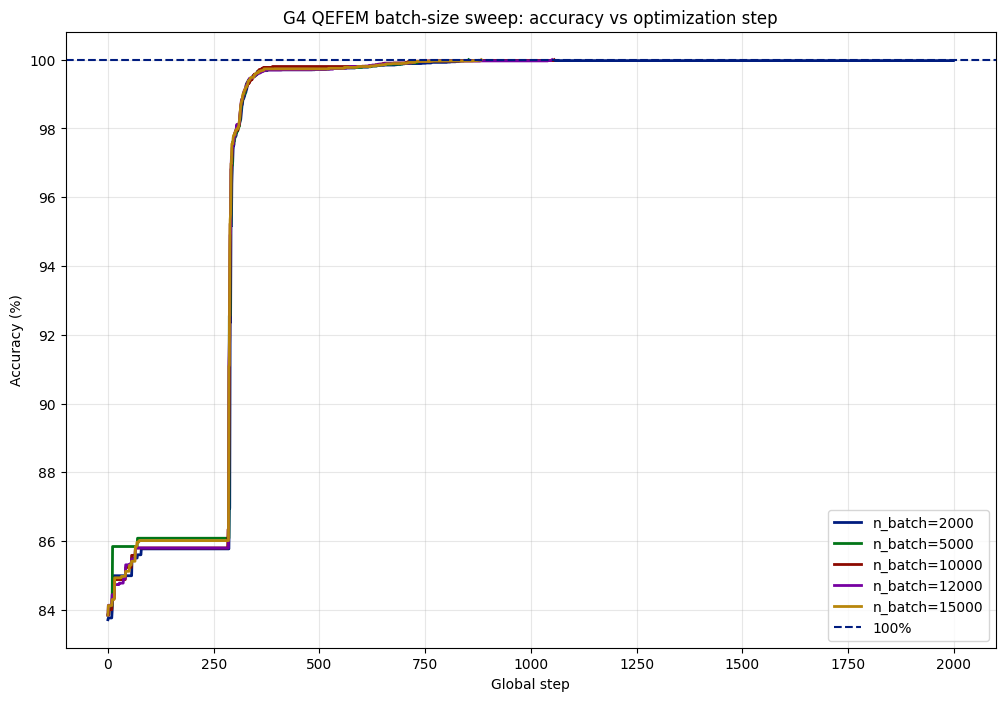

In [102]:
plot_accuracy_sweep(g4_runs)

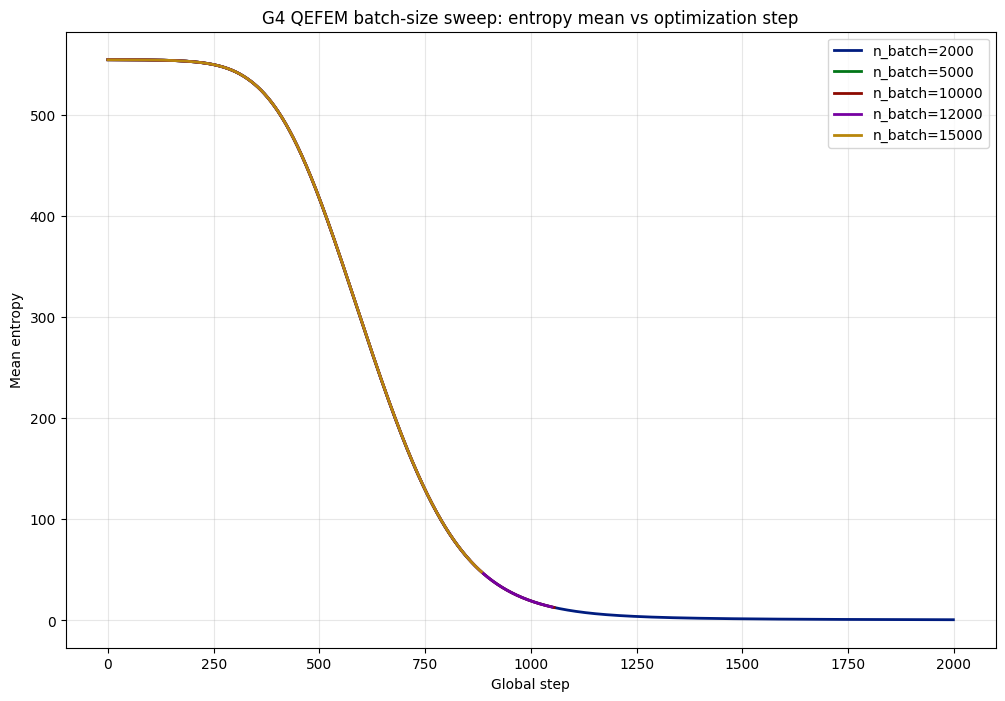

In [103]:
plot_g4_batch_sweep(
    g4_runs,
    y_col="entropy_mean",
    ylabel="Mean entropy",
    title="G4 QEFEM batch-size sweep: entropy mean vs optimization step",
)

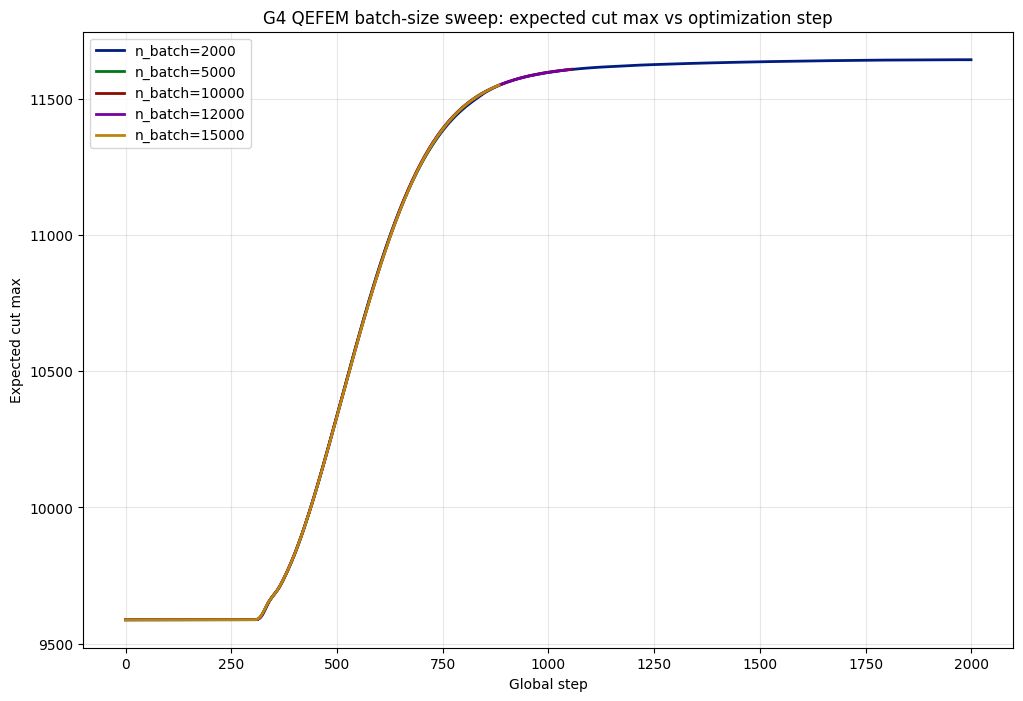

In [104]:
plot_g4_batch_sweep(
    g4_runs,
    y_col="expected_cut_max",
    ylabel="Expected cut max",
    title="G4 QEFEM batch-size sweep: expected cut max vs optimization step",
)

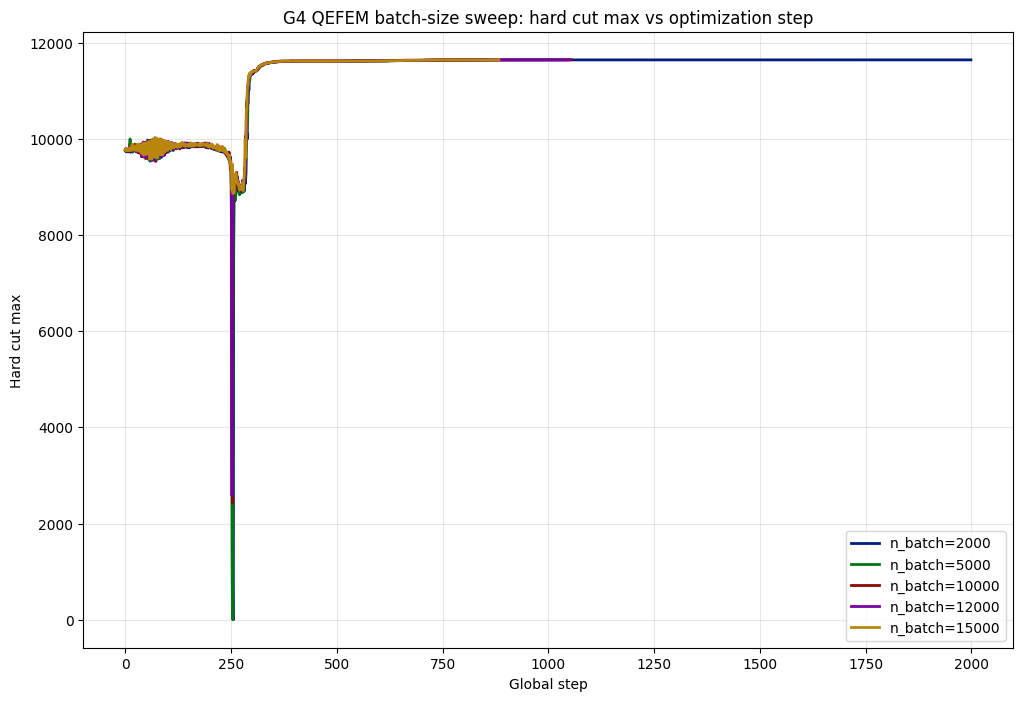

In [105]:
plot_g4_batch_sweep(
    g4_runs,
    y_col="hard_cut_max",
    ylabel="Hard cut max",
    title="G4 QEFEM batch-size sweep: hard cut max vs optimization step",
)

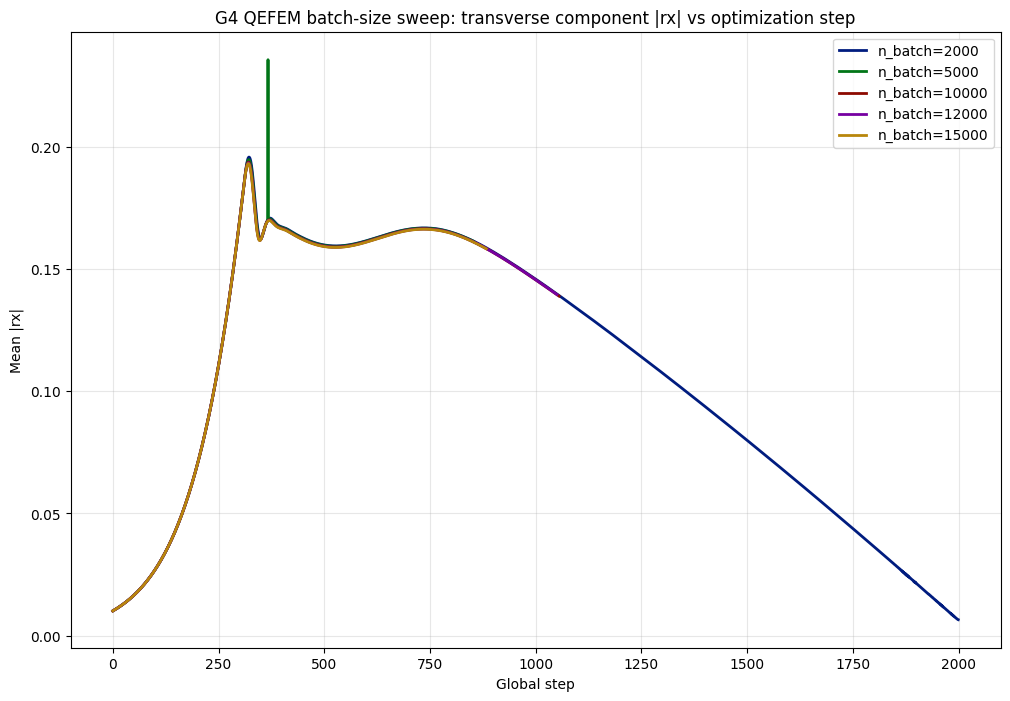

In [106]:
plot_g4_batch_sweep(
    g4_runs,
    y_col="rx_abs_mean",
    ylabel="Mean |rx|",
    title="G4 QEFEM batch-size sweep: transverse component |rx| vs optimization step",
)

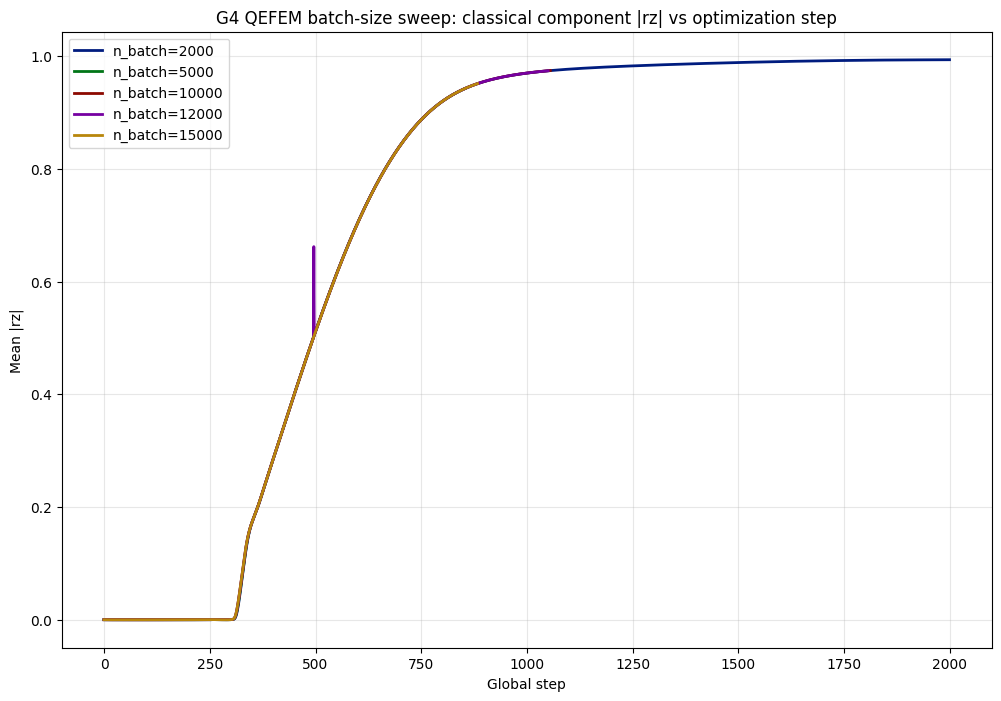

In [107]:
plot_g4_batch_sweep(
    g4_runs,
    y_col="rz_abs_mean",
    ylabel="Mean |rz|",
    title="G4 QEFEM batch-size sweep: classical component |rz| vs optimization step",
)

In [108]:
import pandas as pd
import numpy as np

def get_closure_table(runs, best_known_cut=11646):
    rows = []

    for label, result in runs.items():
        history = result["history"]
        summary = result["summary"]

        success_rows = history[history["gap_so_far"] <= 0]

        if len(success_rows) > 0:
            first_success_step = int(success_rows["global_step"].iloc[0])
            first_success_acc = float(success_rows["accuracy_so_far"].iloc[0])
            closed = True
        else:
            first_success_step = np.nan
            first_success_acc = np.nan
            closed = False

        rows.append({
            "run": label,
            "n_batch": summary["n_batch"],
            "best_cut": summary["best_cut"],
            "gap": summary["gap"],
            "accuracy_percent": 100.0 * summary["accuracy"],
            "best_step": summary["best_step"],
            "closed_gap": closed,
            "first_success_step": first_success_step,
            "first_success_accuracy_percent": 100.0 * first_success_acc if closed else np.nan,
            "history_len": len(history),
        })

    return pd.DataFrame(rows)


closure_df = get_closure_table(g4_runs)
closure_df

,run,n_batch,best_cut,gap,accuracy_percent,best_step,closed_gap,first_success_step,first_success_accuracy_percent,history_len
0,n_batch=2000,2000,11643.0,3.0,99.97424,835,False,NaN,NaN,2000
1,n_batch=5000,5000,11646.0,0.0,100.00000,853,True,853.0,100.0,854
2,n_batch=10000,10000,11646.0,0.0,100.00000,1055,True,1055.0,100.0,1056
3,n_batch=12000,12000,11646.0,0.0,100.00000,1050,True,1050.0,100.0,1051
4,n_batch=15000,15000,11646.0,0.0,100.00000,883,True,883.0,100.0,884


In [109]:
def plot_gap_closure_steps(closure_df):
    plot_df = closure_df.copy()

    plt.figure(figsize=(10, 6))

    closed_df = plot_df[plot_df["closed_gap"] == True]
    failed_df = plot_df[plot_df["closed_gap"] == False]

    plt.scatter(
        closed_df["n_batch"],
        closed_df["first_success_step"],
        s=90,
        label="Closed gap",
    )

    if len(failed_df) > 0:
        plt.scatter(
            failed_df["n_batch"],
            failed_df["history_len"],
            s=90,
            marker="x",
            label="Did not close gap",
        )

    plt.xlabel("n_batch")
    plt.ylabel("First gap-closure step")
    plt.title("G4 QEFEM: first gap-closure step vs batch size")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

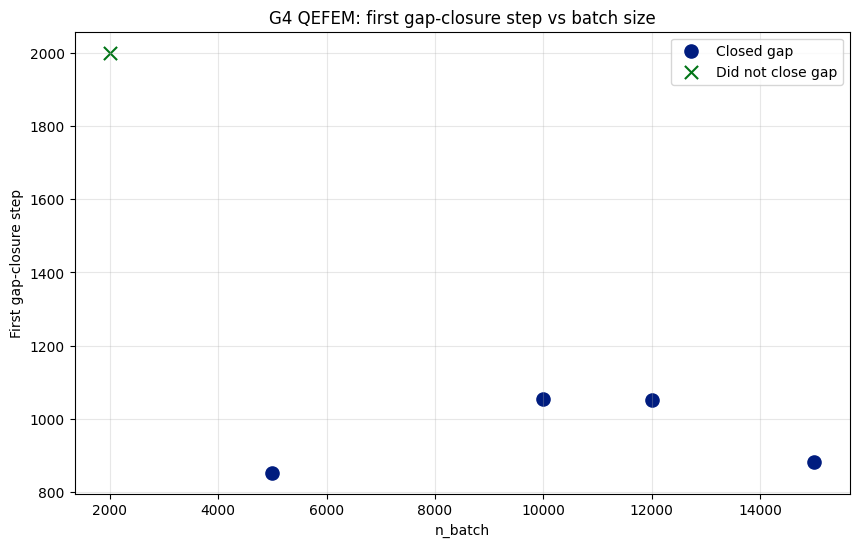

In [110]:
plot_gap_closure_steps(closure_df)

In [111]:
def plot_best_cut_vs_batch(closure_df, best_known_cut=11646):
    plt.figure(figsize=(10, 6))

    plt.plot(
        closure_df["n_batch"],
        closure_df["best_cut"],
        marker="o",
        linewidth=2,
        label="Best cut",
    )

    plt.axhline(
        best_known_cut,
        linestyle="--",
        linewidth=1.5,
        label="Best known",
    )

    plt.xlabel("n_batch")
    plt.ylabel("Best hard cut")
    plt.title("G4 QEFEM: best cut vs batch size")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

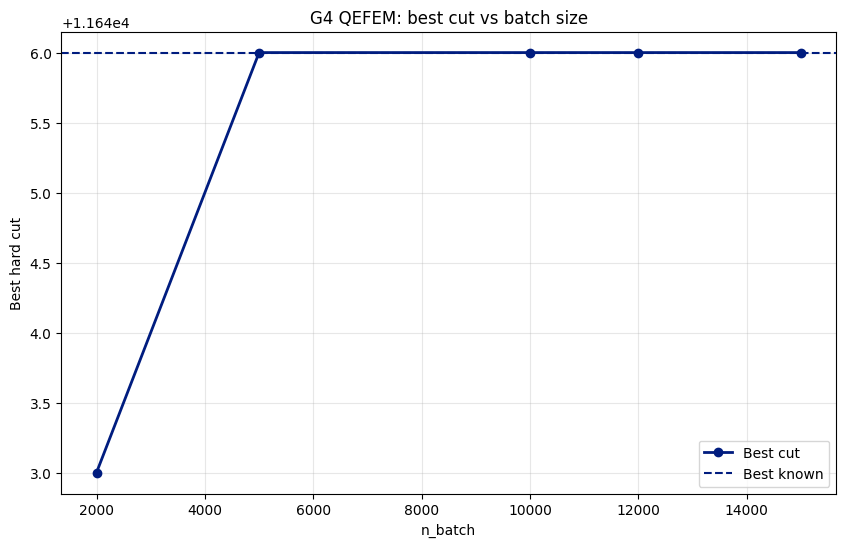

In [112]:
plot_best_cut_vs_batch(closure_df)

In [113]:
def plot_gap_vs_batch(closure_df):
    plt.figure(figsize=(10, 6))

    plt.plot(
        closure_df["n_batch"],
        closure_df["gap"],
        marker="o",
        linewidth=2,
    )

    plt.axhline(0.0, linestyle="--", linewidth=1.5)

    plt.xlabel("n_batch")
    plt.ylabel("Final gap")
    plt.title("G4 QEFEM: final gap vs batch size")
    plt.grid(True, alpha=0.3)
    plt.show()

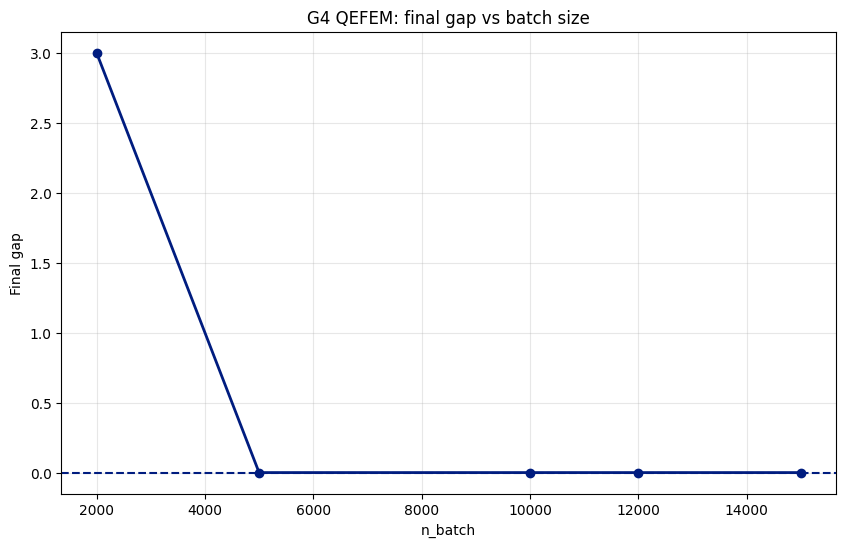

In [114]:
plot_gap_vs_batch(closure_df)

In [115]:
def make_batch_sweep_summary(runs):
    rows = []

    for n_batch, result in runs.items():
        s = result["summary"]
        h = result["history"]

        success_rows = h[h["gap_so_far"] <= 0]

        if len(success_rows) > 0:
            first_success_step = int(success_rows["global_step"].iloc[0])
            closed_gap = True
        else:
            first_success_step = np.nan
            closed_gap = False

        rows.append({
            "n_batch": n_batch,
            "best_cut": s["best_cut"],
            "gap": s["gap"],
            "accuracy_percent": 100.0 * s["accuracy"],
            "best_step": s["best_step"],
            "closed_gap": closed_gap,
            "first_success_step": first_success_step,
            "history_len": len(h),
            "elapsed_sec": s["elapsed_sec"],
        })

    return pd.DataFrame(rows).sort_values("n_batch")


batch_summary = make_batch_sweep_summary(g4_runs)
batch_summary

,n_batch,best_cut,gap,accuracy_percent,best_step,closed_gap,first_success_step,history_len,elapsed_sec
2,n_batch=10000,11646.0,0.0,100.00000,1055,True,1055.0,1056,243.415779
3,n_batch=12000,11646.0,0.0,100.00000,1050,True,1050.0,1051,292.716069
4,n_batch=15000,11646.0,0.0,100.00000,883,True,883.0,884,323.514093
0,n_batch=2000,11643.0,3.0,99.97424,835,False,NaN,2000,97.398337
1,n_batch=5000,11646.0,0.0,100.00000,853,True,853.0,854,93.795459


In [116]:
def plot_final_gap_vs_batch(batch_summary):
    plt.figure(figsize=(10, 6))

    plt.plot(
        batch_summary["n_batch"],
        batch_summary["gap"],
        marker="o",
        linewidth=2,
    )

    plt.axhline(0.0, linestyle="--", linewidth=1.5)

    plt.xlabel("n_batch")
    plt.ylabel("Final gap")
    plt.title("G4 QEFEM: final gap vs batch size")
    plt.grid(True, alpha=0.3)
    plt.show()

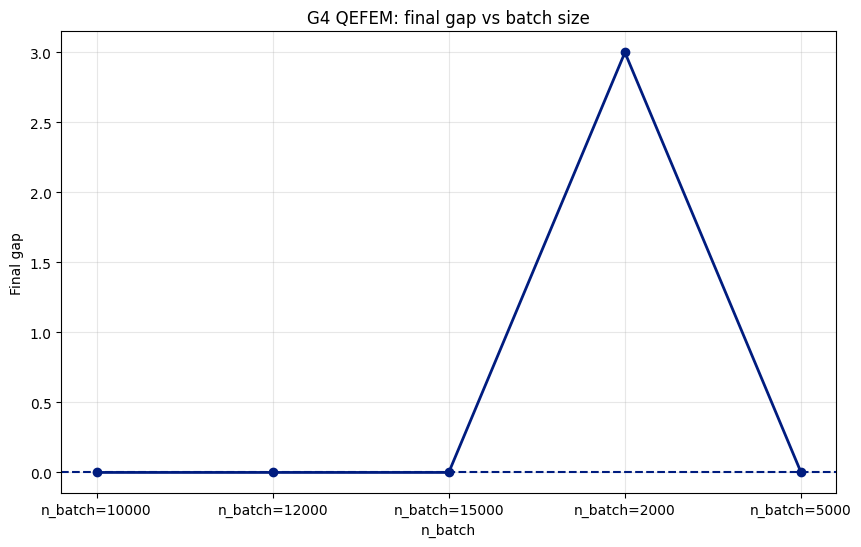

In [117]:
plot_final_gap_vs_batch(batch_summary)

In [118]:
def plot_best_cut_vs_batch(batch_summary, best_known_cut=11646):
    plt.figure(figsize=(10, 6))

    plt.plot(
        batch_summary["n_batch"],
        batch_summary["best_cut"],
        marker="o",
        linewidth=2,
    )

    plt.axhline(
        best_known_cut,
        linestyle="--",
        linewidth=1.5,
        label="Best known",
    )

    plt.xlabel("n_batch")
    plt.ylabel("Best cut")
    plt.title("G4 QEFEM: best cut vs batch size")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

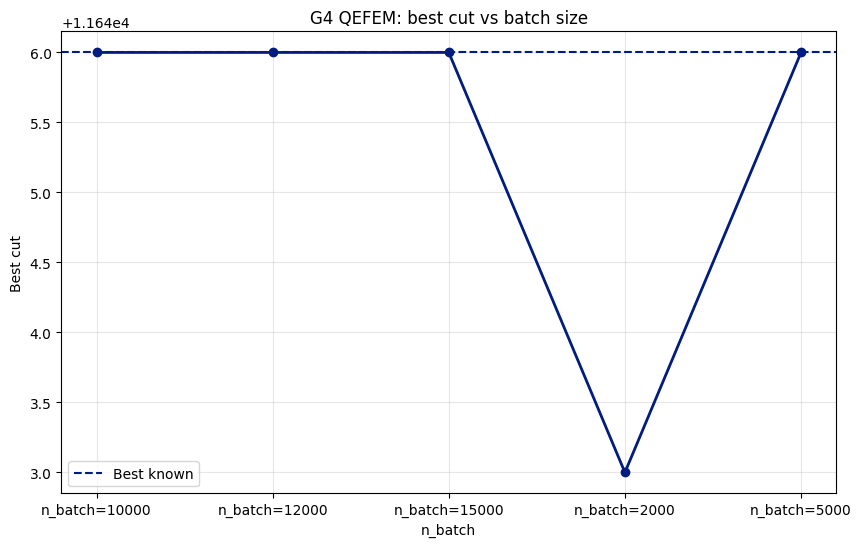

In [119]:
plot_best_cut_vs_batch(batch_summary)

In [120]:
def plot_best_cut_vs_batch(batch_summary, best_known_cut=11646):
    plt.figure(figsize=(10, 6))

    plt.plot(
        batch_summary["n_batch"],
        batch_summary["best_cut"],
        marker="o",
        linewidth=2,
    )

    plt.axhline(
        best_known_cut,
        linestyle="--",
        linewidth=1.5,
        label="Best known",
    )

    plt.xlabel("n_batch")
    plt.ylabel("Best cut")
    plt.title("G4 QEFEM: best cut vs batch size")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

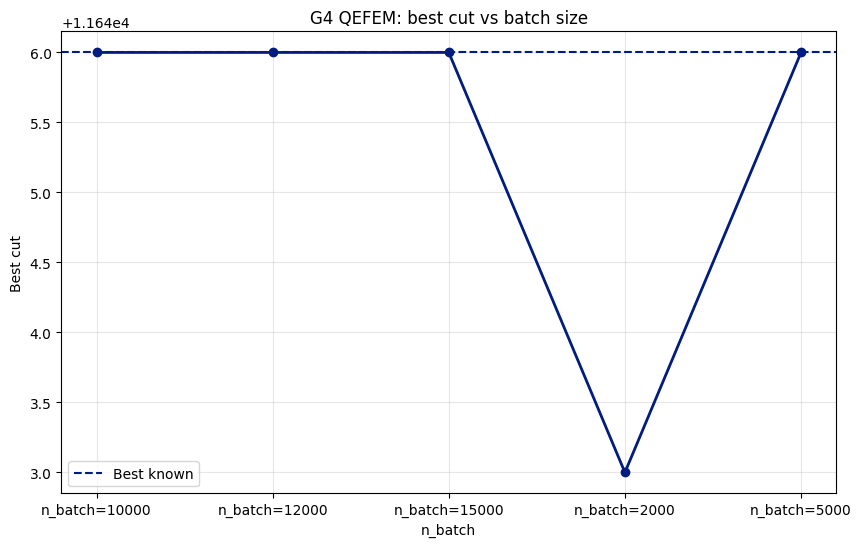

In [121]:
plot_best_cut_vs_batch(batch_summary)

In [122]:
def plot_success_by_batch(batch_summary):
    plt.figure(figsize=(10, 6))

    y = batch_summary["closed_gap"].astype(int)

    plt.bar(
        batch_summary["n_batch"].astype(str),
        y,
    )

    plt.xlabel("n_batch")
    plt.ylabel("Closed gap? 1=yes, 0=no")
    plt.title("G4 QEFEM: gap closure success by batch size")
    plt.grid(True, axis="y", alpha=0.3)
    plt.show()

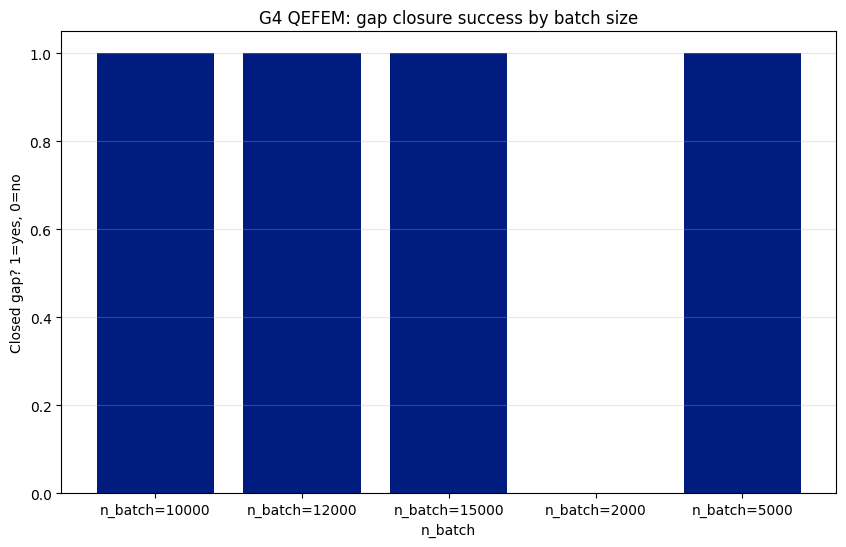

In [123]:
plot_success_by_batch(batch_summary)

In [ ]:
k2000_hparams = get_k2000_local_hparams("adam")

k2000_result = run_qefem_single_instance(
    W=W_K2000,
    best_known_cut=K2000_HIST_BEST,
    local_hparams=k2000_hparams,
    seed=0,
    print_every=50,
)

In [ ]:
k2000_result["summary"]